*** In the Name of God, the Most Gracious, the Most Merciful ***

##Step 1: Problem Statement
We aim to design a machine learning model that, given a set of inputs regarding the structural features of different brain regions, can predict the presence or absence of epilepsy. If the model meets the necessary evaluation criteria, it will be published in a paper based on the current data. Currently, epilepsy diagnosis is based on clinical symptoms, electroencephalography, and MRI images.

Learning Type: Supervised/Binary and Multi-class Classification/Task-oriented
As this is a classification model, we will use "accuracy" and "recall" metrics, as well as "precision-recall" and ROC curves to evaluate different binary and multi-class classification models.
Our expected accuracy and recall are P and R, respectively.
Our assumption in this problem is that the model, upon receiving a signal containing demographic features and structural features of different brain regions, will predict the presence of epilepsy.



In [137]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.impute import KNNImputer
from sklearn.preprocessing import OrdinalEncoder,OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.utils import resample
from sklearn.model_selection import StratifiedKFold, KFold
import tensorflow as tf
from sklearn.preprocessing import label_binarize, Binarizer
from sklearn.model_selection import cross_val_predict, cross_val_score, GridSearchCV
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew

import warnings
warnings.filterwarnings("ignore")

from sklearn.base import BaseEstimator, TransformerMixin, clone
from sklearn.pipeline import Pipeline

from sklearn.feature_selection import SelectFromModel

from sklearn.linear_model import (
    LinearRegression,
    LogisticRegression,
    SGDClassifier
)

from sklearn.svm import SVC

from sklearn.ensemble import (
    GradientBoostingClassifier,
    RandomForestClassifier
)

from sklearn.neighbors import KNeighborsClassifier

from sklearn.naive_bayes import (
    GaussianNB,
    BernoulliNB
)

from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

from lightgbm import LGBMClassifier

##Step 2: Data Acquisition
We used the dataset available on the OpenNeuro database. This dataset contains information on 170 patients. The dataset is accessible at the following address with the DOI: 10.18112/openneuro.ds004199.v1.0.5:
https://openneuro.org/datasets/ds004199/versions/1.0.5

We reconstructed this dataset on a Linux system and extracted the data into two datasets (Dataset 1 using the Desikan atlas and Dataset 2 using the Destrieux atlas).

In [138]:
df=pd.read_csv('df_destx.csv')

In [139]:
df.drop(['Unnamed: 0.1','Unnamed: 0','age_epilepsyonset','map','spect','pet','invasive_EEG','op','age_op','histopathology','1year_outcome','latest_outcome','time_follow-up','hemisphere','lobe'],axis=1,inplace=True)

In [140]:
df.head(10)

,group,sex,age_scan,mri_diagnosis,Left-Lateral-VentricleVolume_mm3,Left-Inf-Lat-VentVolume_mm3,Left-Cerebellum-White-MatterVolume_mm3,Left-Cerebellum-CortexVolume_mm3,Left-ThalamusVolume_mm3,Left-CaudateVolume_mm3,...,RightDestxS_temporal_supFoldInd,RightDestxS_temporal_supCurvInd,RightDestxS_temporal_transverseSurfArea_mm2,RightDestxS_temporal_transverseGrayVol_mm2,RightDestxS_temporal_transverseThickAvg_mm,RightDestxS_temporal_transverseThickStd_mm,RightDestxS_temporal_transverseMeanCurv_mm^-1,RightDestxS_temporal_transverseGausCurv_m^-2,RightDestxS_temporal_transverseFoldInd,RightDestxS_temporal_transverseCurvInd
0,fcd,M,4,suspicion,12071.1,329.2,18754.2,71193.8,9283.2,3704.5,...,43,6.0,283,565,283,0.432,0.109,0.017,2,0.3
1,hc,F,12,NaN,8274.9,214.9,13945.8,51171.9,6859.9,3122.3,...,34,4.0,121,270,121,0.336,0.106,0.015,1,0.1
2,fcd,M,11,suspicion,6748.1,279.1,18710.2,61899.9,8477.7,3392.2,...,42,6.3,268,561,268,0.374,0.110,0.017,2,0.3
3,fcd,M,6,suspicion,3854.7,205.3,21447.6,59488.5,7953.5,3683.1,...,38,5.1,104,210,104,0.373,0.118,0.023,1,0.1
4,hc,F,12,NaN,8558.5,276.1,13266.8,50170.0,7594.1,3149.9,...,34,4.6,146,258,146,0.326,0.110,0.013,1,0.1
5,fcd,M,5,suspicion,6201.1,210.3,14517.3,63612.5,8588.9,4198.0,...,48,5.5,316,481,316,0.429,0.124,0.018,3,0.4
6,hc,F,12,NaN,6577.3,134.1,12359.7,49245.8,7591.9,2809.4,...,38,4.8,247,478,247,0.335,0.154,0.029,3,0.5
7,hc,F,9,NaN,5635.9,266.3,15747.2,55345.6,8903.7,3126.7,...,23,2.9,210,439,210,0.528,0.116,0.021,2,0.3
8,fcd,M,4,suspicion,8132.0,184.6,18826.3,52652.7,9601.2,3954.0,...,48,5.5,220,360,220,0.525,0.156,0.019,4,0.3
9,hc,F,6,NaN,8784.3,380.4,13567.1,60921.6,7067.3,4047.6,...,37,4.4,254,585,254,0.605,0.112,0.020,2,0.3


In [141]:
def DataFrameSplitter(ds):
  df_cat=ds.loc[:,['group','sex','age_scan','mri_diagnosis']]
  df_num=ds.drop(['group','sex','age_scan','mri_diagnosis'],axis=1)
  return df_cat,df_num
df_cat,df_num=DataFrameSplitter(df)

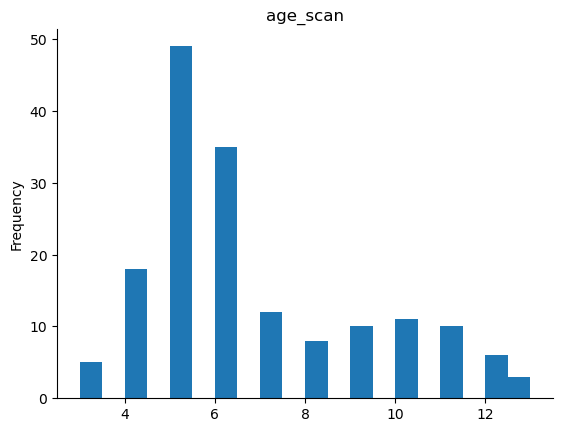

In [142]:
# @title age_scan

df_cat['age_scan'].plot(kind='hist', bins=20, title='age_scan')
plt.gca().spines[['top', 'right',]].set_visible(False)

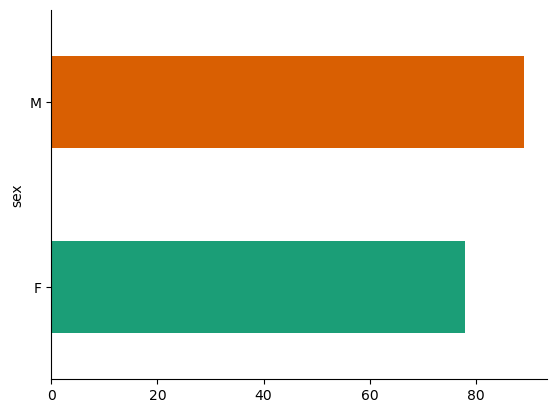

In [143]:
# @title sex

df_cat.groupby('sex').size().plot(kind='barh', color=sns.palettes.mpl_palette('Dark2'))
plt.gca().spines[['top', 'right',]].set_visible(False)

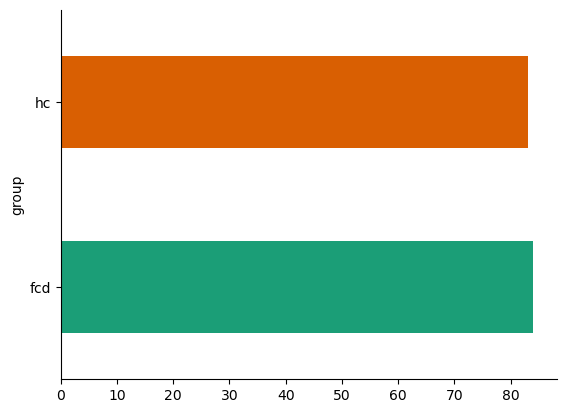

In [144]:
# @title group

df_cat.groupby('group').size().plot(kind='barh', color=sns.palettes.mpl_palette('Dark2'))
plt.gca().spines[['top', 'right',]].set_visible(False)

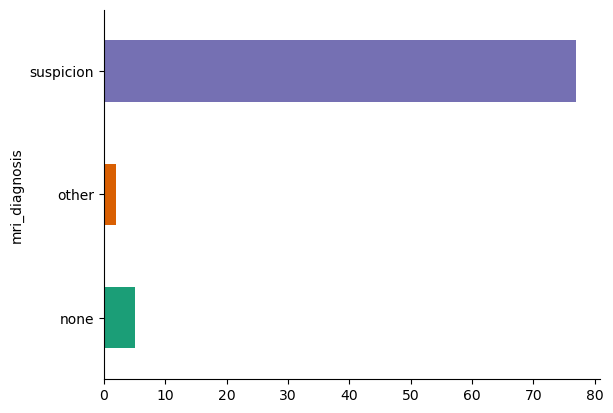

In [145]:
# @title mri_diagnosis

df_cat.groupby('mri_diagnosis').size().plot(kind='barh', color=sns.palettes.mpl_palette('Dark2'))
plt.gca().spines[['top', 'right',]].set_visible(False)

According to the study by Hedman and colleagues in 2011 (https://doi.org/10.1002/hbm.21334), the stages of brain structural development are as follows:

1. Birth to 9 years
2. 9 to 13 years
3. 13 to 18 years
4. 18 to 35 years
5. 35 to 60 years
6. 60 years and older

Therefore, we will modify the "age_scan" feature to a variable with 6 values based on the above pattern.

In [146]:
def CatCorrector(ds):
  for i in ds.index:
    #"group" correction
    ds.group.replace('fcd',1,inplace=True)
    ds.group.replace('hc',0,inplace=True)
    #"sex" correction
    ds.sex.replace('F',1,inplace=True)
    ds.sex.replace('M',0,inplace=True)
    #"age" correction
    age_group = ds.loc[i,'age_scan']
    if age_group < 3:
      ds.loc[i,'age_scan'] =1
    elif age_group == 3:
      ds.loc[i,'age_scan'] = 2
    elif age_group == 4:
      ds.loc[i,'age_scan'] = 3
    elif 4 < age_group < 8:
      ds.loc[i,'age_scan'] = 4
    elif 8 <= age_group < 13:
      ds.loc[i,'age_scan'] = 5
    elif age_group == 13:
      ds.loc[i,'age_scan'] = 6
  ds['age_scan']='age_group_'+ds['age_scan'].astype('<U10')


In [147]:
CatCorrector(df_cat)

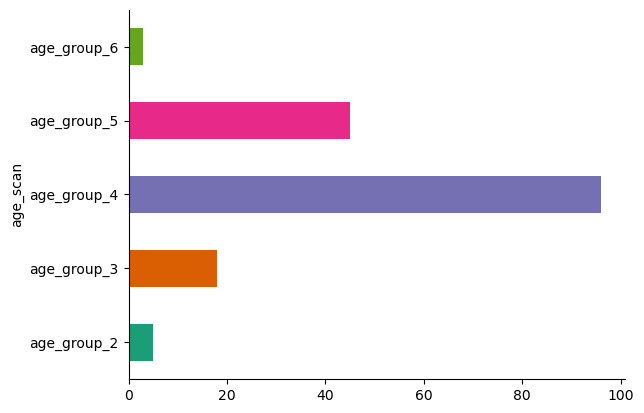

In [148]:
# @title age_scan

df_cat.groupby('age_scan').size().plot(kind='barh', color=sns.palettes.mpl_palette('Dark2'))
plt.gca().spines[['top', 'right',]].set_visible(False)

In [149]:
df_num.describe()

,Left-Lateral-VentricleVolume_mm3,Left-Inf-Lat-VentVolume_mm3,Left-Cerebellum-White-MatterVolume_mm3,Left-Cerebellum-CortexVolume_mm3,Left-ThalamusVolume_mm3,Left-CaudateVolume_mm3,Left-PutamenVolume_mm3,Left-PallidumVolume_mm3,3rd-VentricleVolume_mm3,4th-VentricleVolume_mm3,...,RightDestxS_temporal_supFoldInd,RightDestxS_temporal_supCurvInd,RightDestxS_temporal_transverseSurfArea_mm2,RightDestxS_temporal_transverseGrayVol_mm2,RightDestxS_temporal_transverseThickAvg_mm,RightDestxS_temporal_transverseThickStd_mm,RightDestxS_temporal_transverseMeanCurv_mm^-1,RightDestxS_temporal_transverseGausCurv_m^-2,RightDestxS_temporal_transverseFoldInd,RightDestxS_temporal_transverseCurvInd
count,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,...,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000
mean,7600.347305,261.252695,16498.936527,57716.908383,8407.992814,3576.808383,4641.537725,2091.200599,1021.819760,1834.912575,...,39.401198,5.091018,214.526946,450.335329,214.526946,0.428096,0.122533,0.018988,2.233533,0.273054
std,4232.320398,146.345629,3900.511785,8133.671811,992.784253,486.619321,698.984341,275.752151,327.026769,471.377602,...,8.771572,0.993947,52.059722,106.358941,52.059722,0.103383,0.015573,0.004514,0.863909,0.094063
min,2192.100000,66.700000,7095.400000,31520.000000,5734.800000,2415.600000,2894.300000,1430.000000,497.000000,1008.400000,...,22.000000,2.900000,44.000000,88.000000,44.000000,0.232000,0.080000,0.010000,0.000000,0.000000
25%,4965.050000,166.750000,13863.050000,52346.100000,7742.650000,3230.350000,4199.050000,1901.850000,802.100000,1486.800000,...,34.000000,4.300000,180.000000,386.500000,180.000000,0.348000,0.111000,0.016000,2.000000,0.200000
50%,6758.900000,235.900000,15779.000000,57137.200000,8343.600000,3637.400000,4680.700000,2096.800000,980.200000,1757.500000,...,38.000000,4.900000,212.000000,445.000000,212.000000,0.412000,0.121000,0.018000,2.000000,0.300000
75%,8634.000000,310.450000,18093.500000,63063.600000,9086.650000,3889.800000,5132.050000,2264.700000,1133.000000,2085.600000,...,45.000000,5.700000,254.500000,516.500000,254.500000,0.487000,0.132000,0.022000,3.000000,0.300000
max,26819.400000,1049.500000,31789.800000,79529.300000,10763.100000,4600.300000,6461.200000,3041.300000,2739.100000,3407.700000,...,64.000000,8.100000,337.000000,788.000000,337.000000,0.835000,0.166000,0.037000,5.000000,0.600000


In [150]:
# train_df,test_df=train_test_split(df,test_size=0.2,random_state=42,stratify=df['group'])
train_df=df

##Step 3: Data exploration


In [151]:
train_df.head(10)

,group,sex,age_scan,mri_diagnosis,Left-Lateral-VentricleVolume_mm3,Left-Inf-Lat-VentVolume_mm3,Left-Cerebellum-White-MatterVolume_mm3,Left-Cerebellum-CortexVolume_mm3,Left-ThalamusVolume_mm3,Left-CaudateVolume_mm3,...,RightDestxS_temporal_supFoldInd,RightDestxS_temporal_supCurvInd,RightDestxS_temporal_transverseSurfArea_mm2,RightDestxS_temporal_transverseGrayVol_mm2,RightDestxS_temporal_transverseThickAvg_mm,RightDestxS_temporal_transverseThickStd_mm,RightDestxS_temporal_transverseMeanCurv_mm^-1,RightDestxS_temporal_transverseGausCurv_m^-2,RightDestxS_temporal_transverseFoldInd,RightDestxS_temporal_transverseCurvInd
0,fcd,M,4,suspicion,12071.1,329.2,18754.2,71193.8,9283.2,3704.5,...,43,6.0,283,565,283,0.432,0.109,0.017,2,0.3
1,hc,F,12,NaN,8274.9,214.9,13945.8,51171.9,6859.9,3122.3,...,34,4.0,121,270,121,0.336,0.106,0.015,1,0.1
2,fcd,M,11,suspicion,6748.1,279.1,18710.2,61899.9,8477.7,3392.2,...,42,6.3,268,561,268,0.374,0.110,0.017,2,0.3
3,fcd,M,6,suspicion,3854.7,205.3,21447.6,59488.5,7953.5,3683.1,...,38,5.1,104,210,104,0.373,0.118,0.023,1,0.1
4,hc,F,12,NaN,8558.5,276.1,13266.8,50170.0,7594.1,3149.9,...,34,4.6,146,258,146,0.326,0.110,0.013,1,0.1
5,fcd,M,5,suspicion,6201.1,210.3,14517.3,63612.5,8588.9,4198.0,...,48,5.5,316,481,316,0.429,0.124,0.018,3,0.4
6,hc,F,12,NaN,6577.3,134.1,12359.7,49245.8,7591.9,2809.4,...,38,4.8,247,478,247,0.335,0.154,0.029,3,0.5
7,hc,F,9,NaN,5635.9,266.3,15747.2,55345.6,8903.7,3126.7,...,23,2.9,210,439,210,0.528,0.116,0.021,2,0.3
8,fcd,M,4,suspicion,8132.0,184.6,18826.3,52652.7,9601.2,3954.0,...,48,5.5,220,360,220,0.525,0.156,0.019,4,0.3
9,hc,F,6,NaN,8784.3,380.4,13567.1,60921.6,7067.3,4047.6,...,37,4.4,254,585,254,0.605,0.112,0.020,2,0.3


In [152]:
train_df_cat,train_df_num=DataFrameSplitter(train_df)
CatCorrector(train_df_cat)

In [153]:
train_df_cat

,group,sex,age_scan,mri_diagnosis
0,1,0,age_group_3,suspicion
1,0,1,age_group_5,NaN
2,1,0,age_group_5,suspicion
3,1,0,age_group_4,suspicion
4,0,1,age_group_5,NaN
...,...,...,...,...
162,0,1,age_group_4,NaN
163,0,1,age_group_4,NaN
164,0,0,age_group_4,NaN
165,0,1,age_group_4,NaN


In [154]:

ordinal_encoder = OrdinalEncoder()
age_group_ordinal_encoded = ordinal_encoder.fit_transform(train_df_cat[['age_scan']])
age_group_ordinal_encoded_matrix=pd.DataFrame(age_group_ordinal_encoded,columns=['AgeGroup'])
age_group_ordinal_encoded_matrix.index=train_df_cat.index
train_df_cat.age_scan=age_group_ordinal_encoded_matrix.AgeGroup

In [155]:
train_df_cat

,group,sex,age_scan,mri_diagnosis
0,1,0,1.0,suspicion
1,0,1,3.0,NaN
2,1,0,3.0,suspicion
3,1,0,2.0,suspicion
4,0,1,3.0,NaN
...,...,...,...,...
162,0,1,2.0,NaN
163,0,1,2.0,NaN
164,0,0,2.0,NaN
165,0,1,2.0,NaN


In [18]:
data = pd.DataFrame()
data["age_group_before"] = df['age_scan']
data["age_group_after"] = train_df_cat['age_scan']

before = data["age_group_before"].to_numpy()
after = data["age_group_after"].to_numpy()

observed_skew_before = skew(before, bias=False)
observed_skew_after = skew(after, bias=False)

# define before - after difference
observed_difference = observed_skew_before - observed_skew_after

print(f"Skewness before: {observed_skew_before:.4f}")
print(f"Skewness after:  {observed_skew_after:.4f}")
print(f"Difference:      {observed_difference:.4f}")

Skewness before: 0.9065
Skewness after:  -0.4057
Difference:      1.3122


In [115]:
from scipy.stats import skew
import numpy as np

rng = np.random.default_rng(42)

n_bootstrap = 1000
n = len(data)

# Observed skewness
observed_skew_before = skew(
    before,
    bias=False
)

observed_skew_after = skew(
    after,
    bias=False
)

observed_difference = (
    observed_skew_before
    - observed_skew_after
)

# Bootstrap
bootstrap_differences = np.empty(
    n_bootstrap
)

for i in range(n_bootstrap):

    # Paired resampling:
    # the same indices are used for before and after
    indices = rng.integers(
        low=0,
        high=n,
        size=n
    )

    before_sample = before[indices]
    after_sample = after[indices]

    skew_before_sample = skew(
        before_sample,
        bias=False
    )

    skew_after_sample = skew(
        after_sample,
        bias=False
    )

    bootstrap_differences[i] = (
        skew_before_sample
        - skew_after_sample
    )


# -----------------------------------
# 95% percentile bootstrap CI
# -----------------------------------

ci_lower, ci_upper = np.percentile(
    bootstrap_differences,
    [2.5, 97.5]
)


# -----------------------------------
# Two-sided bootstrap p-value
# H0: difference in skewness = 0
# -----------------------------------

p_lower = (
    np.sum(bootstrap_differences <= 0) + 1
) / (
    n_bootstrap + 1
)

p_upper = (
    np.sum(bootstrap_differences >= 0) + 1
) / (
    n_bootstrap + 1
)

p_value = min(
    1.0,
    2 * min(p_lower, p_upper)
)


# -----------------------------------
# Results
# -----------------------------------

print(
    f"Skewness before: "
    f"{observed_skew_before:.4f}"
)

print(
    f"Skewness after:  "
    f"{observed_skew_after:.4f}"
)

print(
    f"Observed difference: "
    f"{observed_difference:.4f}"
)

print(
    "95% bootstrap CI for difference: "
    f"[{ci_lower:.4f}, {ci_upper:.4f}]"
)

print(
    f"Two-sided bootstrap p-value: "
    f"{p_value:.4f}"
)

Skewness before: 0.9065
Skewness after:  -0.4057
Observed difference: 1.3122
95% bootstrap CI for difference: [0.8934, 1.6770]
Two-sided bootstrap p-value: 0.0020


In [20]:
# We retain age alongside the MRI features in X so that the transformer
# uses only the training fold to perform age residualization.

X = pd.DataFrame()
X['age']=train_df_cat['age_scan']
X=pd.concat([X,train_df_num],axis=1)

y = train_df_cat['group'].astype(int).copy()

print("X shape:", X.shape)
print("Class counts:")
print(y.value_counts())

X shape: (167, 708)
Class counts:
group
1    84
0    83
Name: count, dtype: int64


In [21]:
class InvalidConstantFeatureRemover(BaseEstimator, TransformerMixin):

    def __init__(
        self,
        age_column="age",
        variance_threshold=1e-12
    ):
        self.age_column = age_column
        self.variance_threshold = variance_threshold

    def fit(self, X, y=None):
        X = self._check_dataframe(X)

        if self.age_column not in X.columns:
            raise ValueError(
                f"Missing age column: {self.age_column}"
            )

        feature_columns = [
            c for c in X.columns
            if c != self.age_column
        ]

        self.age_median_ = (
            pd.to_numeric(X[self.age_column], errors="coerce")
            .replace([np.inf, -np.inf], np.nan)
            .median()
        )

        self.retained_feature_columns_ = []
        self.feature_medians_ = {}

        for column in feature_columns:
            values = (
                pd.to_numeric(X[column], errors="coerce")
                .replace([np.inf, -np.inf], np.nan)
            )

            median = values.median()
            filled = values.fillna(median)

            if (
                np.isfinite(filled.var(ddof=0))
                and filled.var(ddof=0) > self.variance_threshold
            ):
                self.retained_feature_columns_.append(column)
                self.feature_medians_[column] = median

        if not self.retained_feature_columns_:
            raise ValueError("No valid non-constant MRI features remain.")

        return self

    def transform(self, X):
        X = self._check_dataframe(X)

        age = (
            pd.to_numeric(X[self.age_column], errors="coerce")
            .replace([np.inf, -np.inf], np.nan)
            .fillna(self.age_median_)
        )

        output = pd.DataFrame(
            {self.age_column: age},
            index=X.index
        )

        for column in self.retained_feature_columns_:
            output[column] = (
                pd.to_numeric(X[column], errors="coerce")
                .replace([np.inf, -np.inf], np.nan)
                .fillna(self.feature_medians_[column])
            )

        return output

    @staticmethod
    def _check_dataframe(X):
        if not isinstance(X, pd.DataFrame):
            raise TypeError("Input must be a pandas DataFrame.")
        return X.copy()

In [22]:
class AgeResidualizer(BaseEstimator, TransformerMixin):
    """
    Regress each MRI feature on age using only the training fold.

    Output contains residualized MRI features only;
    age is removed after residualization.
    """

    def __init__(self, age_column="age"):
        self.age_column = age_column

    def fit(self, X, y=None):
        X = self._check_dataframe(X)

        if self.age_column not in X.columns:
            raise ValueError(
                f"Age column '{self.age_column}' not found."
            )

        self.feature_columns_ = [
            c for c in X.columns
            if c != self.age_column
        ]

        age = X[[self.age_column]].to_numpy(dtype=float)

        self.models_ = {}

        for column in self.feature_columns_:
            model = LinearRegression()
            model.fit(
                age,
                X[column].to_numpy(dtype=float)
            )
            self.models_[column] = model

        return self

    def transform(self, X):
        X = self._check_dataframe(X)

        age = X[[self.age_column]].to_numpy(dtype=float)

        residualized = pd.DataFrame(index=X.index)

        for column in self.feature_columns_:
            observed = X[column].to_numpy(dtype=float)
            predicted_age_effect = self.models_[column].predict(age)

            residualized[column] = (
                observed - predicted_age_effect
            )

        return residualized

    @staticmethod
    def _check_dataframe(X):
        if not isinstance(X, pd.DataFrame):
            raise TypeError("Input must be a pandas DataFrame.")
        return X.copy()

In [23]:
class CorrelationFilter(BaseEstimator, TransformerMixin):

    def __init__(self, threshold=0.90):
        self.threshold = threshold

    def fit(self, X, y=None):
        X = self._to_dataframe(X)

        correlation_matrix = (
            X.corr(method="pearson")
            .abs()
        )

        upper_triangle = correlation_matrix.where(
            np.triu(
                np.ones(correlation_matrix.shape),
                k=1
            ).astype(bool)
        )

        self.columns_to_drop_ = [
            column
            for column in upper_triangle.columns
            if any(upper_triangle[column] > self.threshold)
        ]

        self.columns_to_keep_ = [
            column
            for column in X.columns
            if column not in self.columns_to_drop_
        ]

        if not self.columns_to_keep_:
            raise ValueError(
                "Correlation filtering removed all features."
            )

        return self

    def transform(self, X):
        X = self._to_dataframe(X)
        return X.reindex(columns=self.columns_to_keep_).copy()

    @staticmethod
    def _to_dataframe(X):
        if isinstance(X, pd.DataFrame):
            return X.copy()

        return pd.DataFrame(X)

In [24]:
class TargetCorrelationFilter(BaseEstimator, TransformerMixin):

    def __init__(
        self,
        minimum_absolute_correlation=0.10,
        minimum_features=1
    ):
        self.minimum_absolute_correlation = (
            minimum_absolute_correlation
        )
        self.minimum_features = minimum_features

    def fit(self, X, y):
        X = self._to_dataframe(X)
        y = np.asarray(y).ravel()

        correlations = {}

        for column in X.columns:
            values = X[column].to_numpy(dtype=float)

            if np.std(values) == 0:
                correlations[column] = 0.0
            else:
                correlation = np.corrcoef(values, y)[0, 1]

                if np.isnan(correlation):
                    correlation = 0.0

                correlations[column] = float(correlation)

        self.correlations_ = pd.Series(correlations)

        selected = self.correlations_.index[
            self.correlations_.abs()
            > self.minimum_absolute_correlation
        ].tolist()


        if len(selected) < self.minimum_features:
            selected = (
                self.correlations_
                .abs()
                .sort_values(ascending=False)
                .head(self.minimum_features)
                .index
                .tolist()
            )

        self.selected_columns_ = selected

        return self

    def transform(self, X):
        X = self._to_dataframe(X)
        return X.reindex(
            columns=self.selected_columns_
        ).copy()

    @staticmethod
    def _to_dataframe(X):
        if isinstance(X, pd.DataFrame):
            return X.copy()

        return pd.DataFrame(X)

In [25]:
class SafePCA(PCA):

    def fit(self, X, y=None):
        requested = self.n_components

        if isinstance(requested, int):
            maximum_allowed = min(
                X.shape[0] - 1,
                X.shape[1]
            )

            self.actual_n_components_ = min(
                requested,
                maximum_allowed
            )

            self.n_components = self.actual_n_components_

        return super().fit(X, y)

    def fit_transform(self, X, y=None):
        requested = self.n_components

        if isinstance(requested, int):
            maximum_allowed = min(
                X.shape[0] - 1,
                X.shape[1]
            )

            self.actual_n_components_ = min(
                requested,
                maximum_allowed
            )

            self.n_components = self.actual_n_components_

        return super().fit_transform(X, y)

In [26]:
def build_pca_pipeline(classifier, use_binarizer=False):

    steps = [
        (
            "invalid_constant",
            InvalidConstantFeatureRemover(
                age_column=AGE_COLUMN
            )
        ),
        (
            "age_residualizer",
            AgeResidualizer(
                age_column=AGE_COLUMN
            )
        ),
        (
            "correlation_filter",
            CorrelationFilter(
                threshold=0.90
            )
        ),
        (
            "target_filter",
            TargetCorrelationFilter(
                minimum_absolute_correlation=0.10,
                minimum_features=2
            )
        ),
        (
            "scaler",
            StandardScaler()
        ),
        (
            "pca",
            SafePCA(
                random_state=42
            )
        )
    ]

    if use_binarizer:
        steps.append(
            (
                "binarizer",
                Binarizer(threshold=0.0)
            )
        )

    steps.append(
        ("classifier", classifier)
    )

    return Pipeline(steps)

In [27]:
def make_elastic_net_selector():
    elastic_net_logistic = LogisticRegression(
        penalty="elasticnet",
        solver="saga",
        l1_ratio=0.5,
        C=1.0,
        max_iter=10000,
        class_weight=None,
        random_state=42
    )

    return SelectFromModel(
        estimator=elastic_net_logistic,
        threshold=1e-5
    )

In [28]:
def build_elastic_net_pipeline(
    classifier,
    use_binarizer=False
):

    steps = [
        (
            "invalid_constant",
            InvalidConstantFeatureRemover(
                age_column=AGE_COLUMN
            )
        ),
        (
            "age_residualizer",
            AgeResidualizer(
                age_column=AGE_COLUMN
            )
        ),
        (
            "scaler",
            StandardScaler()
        ),
        (
            "elastic_selector",
            make_elastic_net_selector()
        )
    ]

    if use_binarizer:
        steps.append(
            (
                "binarizer",
                Binarizer(threshold=0.0)
            )
        )

    steps.append(
        ("classifier", classifier)
    )

    return Pipeline(steps)

In [33]:
RANDOM_STATE = 42

models = {
    "Logistic Regression": LogisticRegression(
        max_iter=10000,
        random_state=RANDOM_STATE
    ),

    "SVM": SVC(
        probability=True,
        random_state=RANDOM_STATE
    ),

    "Stochastic Gradient Descent": SGDClassifier(
        loss="log_loss",
        max_iter=5000,
        tol=1e-4,
        random_state=RANDOM_STATE
    ),

    "Gradient Boosting": GradientBoostingClassifier(
        random_state=RANDOM_STATE
    ),

    "LightGBM": LGBMClassifier(
        random_state=RANDOM_STATE,
        verbosity=-1,
        n_jobs=1
    ),

    "Random Forest": RandomForestClassifier(
        random_state=RANDOM_STATE,
        n_jobs=1
    ),

    "KNN": KNeighborsClassifier(),

    "Gaussian Naive Bayes": GaussianNB(),

    "Bernoulli Naive Bayes": BernoulliNB(),

    "Decision Tree": DecisionTreeClassifier(
        random_state=RANDOM_STATE
    ),

    "Neural Network": MLPClassifier(
        max_iter=3000,
        early_stopping=True,
        random_state=RANDOM_STATE
    )
}

In [29]:
model_param_grids = {
    "Logistic Regression": {
        "classifier__C": [0.01, 0.1, 1, 10],
        "classifier__class_weight": [None, "balanced"]
    },

    "SVM": {
        "classifier__C": [0.1, 1, 10],
        "classifier__kernel": ["linear", "rbf"],
        "classifier__gamma": ["scale", 0.01, 0.1],
        "classifier__class_weight": [None, "balanced"]
    },

    "Stochastic Gradient Descent": {
        "classifier__alpha": [1e-4, 1e-3, 1e-2],
        "classifier__penalty": ["l2", "elasticnet"],
        "classifier__l1_ratio": [0.15, 0.5],
        "classifier__class_weight": [None, "balanced"]
    },

    "Gradient Boosting": {
        "classifier__n_estimators": [50, 100],
        "classifier__learning_rate": [0.03, 0.1],
        "classifier__max_depth": [1, 2, 3]
    },

    "LightGBM": {
        "classifier__n_estimators": [50, 100],
        "classifier__learning_rate": [0.03, 0.1],
        "classifier__num_leaves": [5, 10, 20],
        "classifier__max_depth": [-1, 3, 5],
        "classifier__min_child_samples": [5, 10, 20]
    },

    "Random Forest": {
        "classifier__n_estimators": [200, 500],
        "classifier__max_depth": [None, 3, 5],
        "classifier__min_samples_leaf": [1, 3, 5],
        "classifier__max_features": ["sqrt", 0.5],
        "classifier__class_weight": [None, "balanced"]
    },

    "KNN": {
        "classifier__n_neighbors": [3, 5, 7, 9, 11],
        "classifier__weights": ["uniform", "distance"],
        "classifier__p": [1, 2]
    },

    "Gaussian Naive Bayes": {
        "classifier__var_smoothing": [
            1e-11,
            1e-10,
            1e-9,
            1e-8,
            1e-7
        ]
    },

    "Bernoulli Naive Bayes": {
        "classifier__alpha": [0.1, 0.5, 1.0, 2.0],
        "classifier__fit_prior": [True, False]
    },

    "Decision Tree": {
        "classifier__max_depth": [None, 2, 3, 5],
        "classifier__min_samples_leaf": [1, 3, 5, 10],
        "classifier__criterion": ["gini", "entropy"],
        "classifier__class_weight": [None, "balanced"]
    },

    "Neural Network": {
        "classifier__hidden_layer_sizes": [
            (10,),
            (20,),
            (20, 10)
        ],
        "classifier__alpha": [1e-4, 1e-3, 1e-2],
        "classifier__learning_rate_init": [1e-3, 1e-2]
    }
}

In [30]:
PCA_COMPONENT_OPTIONS = [2, 5, 10, 15, 20, 30]

def get_pca_param_grid(model_name):
    grid = {
        "pca__n_components": PCA_COMPONENT_OPTIONS
    }

    grid.update(model_param_grids[model_name])

    return grid



In [31]:
def get_elastic_net_param_grid(model_name):

    grid = {
        "elastic_selector__estimator__C": [
            0.01,
            0.1,
            1,
            10
        ],
        "elastic_selector__estimator__l1_ratio": [
            0.1,
            0.5,
            0.9
        ],
        "elastic_selector__threshold": [
            1e-5,
            "mean",
            "median"
        ]
    }

    grid.update(model_param_grids[model_name])

    return grid

In [32]:
def get_continuous_scores(estimator, X):

    if hasattr(estimator, "predict_proba"):
        probabilities = estimator.predict_proba(X)

        if probabilities.ndim == 2:
            return probabilities[:, 1]

        return probabilities.ravel()

    if hasattr(estimator, "decision_function"):
        scores = estimator.decision_function(X)
        return np.asarray(scores).ravel()


    return estimator.predict(X).astype(float)

In [ ]:
def run_nested_cv(
    X,
    y,
    pipeline,
    param_grid,
    outer_splits=10,
    inner_splits=5,
    random_state=42,
    verbose=0
):
    X = X.reset_index(drop=True)
    y = pd.Series(y).reset_index(drop=True)

    outer_cv = StratifiedKFold(
        n_splits=outer_splits,
        shuffle=True,
        random_state=random_state
    )

    oof_predictions = np.full(
        shape=len(y),
        fill_value=np.nan
    )

    oof_scores = np.full(
        shape=len(y),
        fill_value=np.nan,
        dtype=float
    )

    fold_records = []
    fitted_models = []

    for outer_fold, (train_index, test_index) in enumerate(
        outer_cv.split(X, y),
        start=1
    ):
        print(
            f"Outer fold {outer_fold}/{outer_splits}"
        )

        X_train = X.iloc[train_index].copy()
        X_test = X.iloc[test_index].copy()

        y_train = y.iloc[train_index].copy()
        y_test = y.iloc[test_index].copy()

        inner_cv = StratifiedKFold(
            n_splits=inner_splits,
            shuffle=True,
            random_state=random_state + outer_fold
        )

        search = GridSearchCV(
            estimator=clone(pipeline),
            param_grid=param_grid,
            scoring="roc_auc",
            cv=inner_cv,
            n_jobs=-1,
            refit=True,
            error_score=np.nan,
            return_train_score=False,
            verbose=verbose
        )

        search.fit(X_train, y_train)

        best_model = search.best_estimator_

        test_predictions = best_model.predict(X_test)
        test_scores = get_continuous_scores(
            best_model,
            X_test
        )

        oof_predictions[test_index] = test_predictions
        oof_scores[test_index] = test_scores

        fold_record = {
            "outer_fold": outer_fold,
            "n_train": len(train_index),
            "n_test": len(test_index),
            "inner_best_auc": search.best_score_,
            "best_params": search.best_params_,
            "outer_accuracy": accuracy_score(
                y_test,
                test_predictions
            ),
            "outer_precision": precision_score(
                y_test,
                test_predictions,
                zero_division=0
            ),
            "outer_recall": recall_score(
                y_test,
                test_predictions,
                zero_division=0
            ),
            "outer_f1": f1_score(
                y_test,
                test_predictions,
                zero_division=0
            ),
            "outer_auc": roc_auc_score(
                y_test,
                test_scores
            )
        }

        fold_records.append(fold_record)
        fitted_models.append(best_model)

    if (
        np.isnan(oof_predictions).any()
        or np.isnan(oof_scores).any()
    ):
        raise RuntimeError(
            "Some participants did not receive an out-of-fold prediction."
        )

    return {
        "y_true": y.to_numpy(),
        "oof_predictions": oof_predictions.astype(int),
        "oof_scores": oof_scores,
        "fold_results": pd.DataFrame(fold_records),
        "fitted_models": fitted_models
    }

In [34]:
def calculate_metrics(
    y_true,
    y_pred,
    y_score
):
    return {
        "Accuracy": accuracy_score(
            y_true,
            y_pred
        ),
        "Precision": precision_score(
            y_true,
            y_pred,
            zero_division=0
        ),
        "Recall": recall_score(
            y_true,
            y_pred,
            zero_division=0
        ),
        "F1-Score": f1_score(
            y_true,
            y_pred,
            zero_division=0
        ),
        "AUC": roc_auc_score(
            y_true,
            y_score
        )
    }

In [35]:
def bootstrap_metric_confidence_intervals(
    y_true,
    y_pred,
    y_score,
    n_bootstrap=1000,
    confidence_level=0.95,
    random_state=42
):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    y_score = np.asarray(y_score)

    rng = np.random.default_rng(random_state)

    point_estimates = calculate_metrics(
        y_true,
        y_pred,
        y_score
    )

    bootstrap_distributions = {
        metric: []
        for metric in point_estimates
    }

    n_samples = len(y_true)
    accepted_iterations = 0
    attempts = 0
    maximum_attempts = n_bootstrap * 10

    while (
        accepted_iterations < n_bootstrap
        and attempts < maximum_attempts
    ):
        attempts += 1

        indices = rng.integers(
            low=0,
            high=n_samples,
            size=n_samples
        )

        y_boot = y_true[indices]


        if np.unique(y_boot).size < 2:
            continue

        pred_boot = y_pred[indices]
        score_boot = y_score[indices]

        bootstrap_metrics = calculate_metrics(
            y_boot,
            pred_boot,
            score_boot
        )

        for metric, value in bootstrap_metrics.items():
            bootstrap_distributions[metric].append(value)

        accepted_iterations += 1

    if accepted_iterations < n_bootstrap:
        raise RuntimeError(
            f"Only {accepted_iterations} valid bootstrap samples obtained."
        )

    alpha = 1 - confidence_level

    lower_percentile = 100 * (alpha / 2)
    upper_percentile = 100 * (1 - alpha / 2)

    rows = []

    for metric, point_estimate in point_estimates.items():
        distribution = np.asarray(
            bootstrap_distributions[metric]
        )

        lower = np.percentile(
            distribution,
            lower_percentile
        )

        upper = np.percentile(
            distribution,
            upper_percentile
        )

        rows.append({
            "Metric": metric,
            "Estimate": point_estimate,
            "CI Lower": lower,
            "CI Upper": upper
        })

    return pd.DataFrame(rows)

In [36]:
def stratified_bootstrap_ci(
    y_true,
    y_pred,
    y_score,
    n_bootstrap=1000,
    random_state=42
):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    y_score = np.asarray(y_score)

    rng = np.random.default_rng(random_state)

    class_zero_indices = np.where(y_true == 0)[0]
    class_one_indices = np.where(y_true == 1)[0]

    point_estimates = calculate_metrics(
        y_true,
        y_pred,
        y_score
    )

    distributions = {
        metric: []
        for metric in point_estimates
    }

    for _ in range(n_bootstrap):
        sampled_zero = rng.choice(
            class_zero_indices,
            size=len(class_zero_indices),
            replace=True
        )

        sampled_one = rng.choice(
            class_one_indices,
            size=len(class_one_indices),
            replace=True
        )

        sampled_indices = np.concatenate(
            [sampled_zero, sampled_one]
        )

        rng.shuffle(sampled_indices)

        metrics = calculate_metrics(
            y_true[sampled_indices],
            y_pred[sampled_indices],
            y_score[sampled_indices]
        )

        for metric, value in metrics.items():
            distributions[metric].append(value)

    rows = []

    for metric, estimate in point_estimates.items():
        distribution = np.asarray(distributions[metric])

        rows.append({
            "Metric": metric,
            "Estimate": estimate,
            "CI Lower": np.percentile(distribution, 2.5),
            "CI Upper": np.percentile(distribution, 97.5)
        })

    return pd.DataFrame(rows)

In [37]:
TARGET_COLUMN = "group"
AGE_COLUMN = "age"

In [44]:
pca_results = {}
pca_summary_tables = []

for model_index, (model_name, model) in enumerate(
    models.items(),
    start=1
):
    print("\n" + "=" * 80)
    print(
        f"PCA pipeline — {model_index}/{len(models)}: "
        f"{model_name}"
    )
    print("=" * 80)

    needs_binarizer = (
        model_name == "Bernoulli Naive Bayes"
    )

    pipeline = build_pca_pipeline(
        classifier=clone(model),
        use_binarizer=needs_binarizer
    )

    param_grid = get_pca_param_grid(
        model_name
    )

    nested_result = run_nested_cv(
        X=X,
        y=y,
        pipeline=pipeline,
        param_grid=param_grid,
        outer_splits=10,
        inner_splits=5,
        random_state=RANDOM_STATE,
        verbose=0
    )

    ci_table = stratified_bootstrap_ci(
        y_true=nested_result["y_true"],
        y_pred=nested_result["oof_predictions"],
        y_score=nested_result["oof_scores"],
        n_bootstrap=1000,
        random_state=RANDOM_STATE + model_index
    )

    ci_table.insert(0, "Model", model_name)
    ci_table.insert(1, "Feature Method", "PCA")

    pca_results[model_name] = {
        **nested_result,
        "metrics_ci": ci_table
    }

    pca_summary_tables.append(ci_table)


PCA pipeline — 1/11: Logistic Regression
Outer fold 1/10


Outer fold 2/10
Outer fold 3/10
Outer fold 4/10
Outer fold 5/10
Outer fold 6/10
Outer fold 7/10
Outer fold 8/10
Outer fold 9/10
Outer fold 10/10

PCA pipeline — 2/11: SVM
Outer fold 1/10
Outer fold 2/10
Outer fold 3/10
Outer fold 4/10
Outer fold 5/10
Outer fold 6/10
Outer fold 7/10
Outer fold 8/10
Outer fold 9/10
Outer fold 10/10

PCA pipeline — 3/11: Stochastic Gradient Descent
Outer fold 1/10
Outer fold 2/10
Outer fold 3/10
Outer fold 4/10
Outer fold 5/10
Outer fold 6/10
Outer fold 7/10
Outer fold 8/10
Outer fold 9/10
Outer fold 10/10

PCA pipeline — 4/11: Gradient Boosting
Outer fold 1/10
Outer fold 2/10
Outer fold 3/10
Outer fold 4/10
Outer fold 5/10
Outer fold 6/10
Outer fold 7/10
Outer fold 8/10
Outer fold 9/10
Outer fold 10/10

PCA pipeline — 5/11: LightGBM
Outer fold 1/10
Outer fold 2/10
Outer fold 3/10
Outer fold 4/10
Outer fold 5/10
Outer fold 6/10
Outer fold 7/10
Outer fold 8/10
Outer fold 9/10
Outer fold 10/10

PCA pipeline — 6/11: Random Forest
Outer fold 1/10
Outer fold 2

In [ ]:
pca_summary = pd.concat(
    pca_summary_tables,
    ignore_index=True
)

print(pca_summary)

                          Model Feature Method     Metric  Estimate  CI Lower  \
0           Logistic Regression            PCA   Accuracy  0.658683  0.586826   
1           Logistic Regression            PCA  Precision  0.670886  0.594928   
2           Logistic Regression            PCA     Recall  0.630952  0.523810   
3           Logistic Regression            PCA   F1-Score  0.650307  0.566038   
4           Logistic Regression            PCA        AUC  0.707401  0.625638   
5                           SVM            PCA   Accuracy  0.646707  0.574850   
6                           SVM            PCA  Precision  0.671233  0.590361   
7                           SVM            PCA     Recall  0.583333  0.476190   
8                           SVM            PCA   F1-Score  0.624204  0.535948   
9                           SVM            PCA        AUC  0.716437  0.637672   
10  Stochastic Gradient Descent            PCA   Accuracy  0.604790  0.532934   
11  Stochastic Gradient Desc

In [46]:
elastic_results = {}
elastic_summary_tables = []

for model_index, (model_name, model) in enumerate(
    models.items(),
    start=1
):
    print("\n" + "=" * 80)
    print(
        f"Elastic Net pipeline — "
        f"{model_index}/{len(models)}: {model_name}"
    )
    print("=" * 80)

    needs_binarizer = (
        model_name == "Bernoulli Naive Bayes"
    )

    pipeline = build_elastic_net_pipeline(
        classifier=clone(model),
        use_binarizer=needs_binarizer
    )

    param_grid = get_elastic_net_param_grid(
        model_name
    )

    nested_result = run_nested_cv(
        X=X,
        y=y,
        pipeline=pipeline,
        param_grid=param_grid,
        outer_splits=10,
        inner_splits=5,
        random_state=RANDOM_STATE,
        verbose=0
    )

    ci_table = stratified_bootstrap_ci(
        y_true=nested_result["y_true"],
        y_pred=nested_result["oof_predictions"],
        y_score=nested_result["oof_scores"],
        n_bootstrap=1000,
        random_state=(
            RANDOM_STATE + 100 + model_index
        )
    )

    ci_table.insert(0, "Model", model_name)
    ci_table.insert(1, "Feature Method", "Elastic Net")

    elastic_results[model_name] = {
        **nested_result,
        "metrics_ci": ci_table
    }

    elastic_summary_tables.append(ci_table)


Elastic Net pipeline — 1/11: Logistic Regression
Outer fold 1/10
Outer fold 2/10
Outer fold 3/10
Outer fold 4/10
Outer fold 5/10
Outer fold 6/10
Outer fold 7/10
Outer fold 8/10
Outer fold 9/10
Outer fold 10/10

Elastic Net pipeline — 2/11: SVM
Outer fold 1/10
Outer fold 2/10
Outer fold 3/10
Outer fold 4/10
Outer fold 5/10
Outer fold 6/10
Outer fold 7/10
Outer fold 8/10
Outer fold 9/10
Outer fold 10/10

Elastic Net pipeline — 3/11: Stochastic Gradient Descent
Outer fold 1/10
Outer fold 2/10
Outer fold 3/10
Outer fold 4/10
Outer fold 5/10
Outer fold 6/10
Outer fold 7/10
Outer fold 8/10
Outer fold 9/10
Outer fold 10/10

Elastic Net pipeline — 4/11: Gradient Boosting
Outer fold 1/10
Outer fold 2/10
Outer fold 3/10
Outer fold 4/10
Outer fold 5/10
Outer fold 6/10
Outer fold 7/10
Outer fold 8/10
Outer fold 9/10
Outer fold 10/10

Elastic Net pipeline — 5/11: LightGBM
Outer fold 1/10
Outer fold 2/10
Outer fold 3/10
Outer fold 4/10
Outer fold 5/10
Outer fold 6/10
Outer fold 7/10
Outer fold 8/10

In [47]:
elastic_summary = pd.concat(
    elastic_summary_tables,
    ignore_index=True
)

print(elastic_summary)

                          Model Feature Method     Metric  Estimate  CI Lower  \
0           Logistic Regression    Elastic Net   Accuracy  0.670659  0.604790   
1           Logistic Regression    Elastic Net  Precision  0.679012  0.606742   
2           Logistic Regression    Elastic Net     Recall  0.654762  0.559524   
3           Logistic Regression    Elastic Net   F1-Score  0.666667  0.591174   
4           Logistic Regression    Elastic Net        AUC  0.701090  0.623917   
5                           SVM    Elastic Net   Accuracy  0.670659  0.598802   
6                           SVM    Elastic Net  Precision  0.670588  0.599943   
7                           SVM    Elastic Net     Recall  0.678571  0.583036   
8                           SVM    Elastic Net   F1-Score  0.674556  0.595238   
9                           SVM    Elastic Net        AUC  0.736948  0.662647   
10  Stochastic Gradient Descent    Elastic Net   Accuracy  0.670659  0.598653   
11  Stochastic Gradient Desc

In [49]:
all_results_long = pd.concat(
    [
        pca_summary,
        elastic_summary
    ],
    ignore_index=True
)

In [50]:
all_results_long["Estimate (95% CI)"] = (
    all_results_long["Estimate"].map(lambda x: f"{x:.3f}")
    + " ("
    + all_results_long["CI Lower"].map(lambda x: f"{x:.3f}")
    + "–"
    + all_results_long["CI Upper"].map(lambda x: f"{x:.3f}")
    + ")"
)

In [51]:
final_results_table = all_results_long.pivot_table(
    index=["Model", "Feature Method"],
    columns="Metric",
    values="Estimate (95% CI)",
    aggfunc="first"
).reset_index()

In [52]:
final_results_table = all_results_long.pivot_table(
    index=["Model", "Feature Method"],
    columns="Metric",
    values="Estimate (95% CI)",
    aggfunc="first"
).reset_index()

In [53]:
final_results_table.to_csv(
    "NestedCV_PCA_vs_ElasticNet_results.csv",
    index=False
)

all_results_long.to_csv(
    "NestedCV_all_metrics_long_format.csv",
    index=False
)

In [54]:
def paired_bootstrap_method_difference(
    y_true,
    pred_a,
    score_a,
    pred_b,
    score_b,
    method_a_name="PCA",
    method_b_name="Elastic Net",
    n_bootstrap=1000,
    random_state=42
):
    """
    Difference = method B - method A
    """

    y_true = np.asarray(y_true)
    pred_a = np.asarray(pred_a)
    score_a = np.asarray(score_a)
    pred_b = np.asarray(pred_b)
    score_b = np.asarray(score_b)

    rng = np.random.default_rng(random_state)

    point_a = calculate_metrics(
        y_true,
        pred_a,
        score_a
    )

    point_b = calculate_metrics(
        y_true,
        pred_b,
        score_b
    )

    differences = {
        metric: []
        for metric in point_a
    }

    n = len(y_true)

    for _ in range(n_bootstrap):
        indices = rng.integers(
            0,
            n,
            size=n
        )

        y_boot = y_true[indices]

        if np.unique(y_boot).size < 2:
            continue

        metrics_a = calculate_metrics(
            y_boot,
            pred_a[indices],
            score_a[indices]
        )

        metrics_b = calculate_metrics(
            y_boot,
            pred_b[indices],
            score_b[indices]
        )

        for metric in differences:
            differences[metric].append(
                metrics_b[metric] - metrics_a[metric]
            )

    rows = []

    for metric in differences:
        distribution = np.asarray(
            differences[metric]
        )

        observed_difference = (
            point_b[metric] - point_a[metric]
        )

        lower = np.percentile(
            distribution,
            2.5
        )

        upper = np.percentile(
            distribution,
            97.5
        )

        # empirical two-sided bootstrap p-value
        p_lower = np.mean(distribution <= 0)
        p_upper = np.mean(distribution >= 0)

        p_value = min(
            1.0,
            2 * min(p_lower, p_upper)
        )

        rows.append({
            "Metric": metric,
            "Difference": (
                f"{method_b_name} - {method_a_name}"
            ),
            "Estimate Difference": observed_difference,
            "CI Lower": lower,
            "CI Upper": upper,
            "Bootstrap p-value": p_value
        })

    return pd.DataFrame(rows)

In [55]:
comparison_tables = []

for model_index, model_name in enumerate(
    models.keys(),
    start=1
):
    pca_result = pca_results[model_name]
    en_result = elastic_results[model_name]

    comparison = paired_bootstrap_method_difference(
        y_true=pca_result["y_true"],
        pred_a=pca_result["oof_predictions"],
        score_a=pca_result["oof_scores"],
        pred_b=en_result["oof_predictions"],
        score_b=en_result["oof_scores"],
        method_a_name="PCA",
        method_b_name="Elastic Net",
        n_bootstrap=1000,
        random_state=1000 + model_index
    )

    comparison.insert(0, "Model", model_name)
    comparison_tables.append(comparison)

In [56]:
pca_vs_elastic_comparison = pd.concat(
    comparison_tables,
    ignore_index=True
)

pca_vs_elastic_comparison.to_csv(
    "PCA_vs_ElasticNet_paired_bootstrap.csv",
    index=False
)

print(pca_vs_elastic_comparison)

                          Model     Metric         Difference  \
0           Logistic Regression   Accuracy  Elastic Net - PCA   
1           Logistic Regression  Precision  Elastic Net - PCA   
2           Logistic Regression     Recall  Elastic Net - PCA   
3           Logistic Regression   F1-Score  Elastic Net - PCA   
4           Logistic Regression        AUC  Elastic Net - PCA   
5                           SVM   Accuracy  Elastic Net - PCA   
6                           SVM  Precision  Elastic Net - PCA   
7                           SVM     Recall  Elastic Net - PCA   
8                           SVM   F1-Score  Elastic Net - PCA   
9                           SVM        AUC  Elastic Net - PCA   
10  Stochastic Gradient Descent   Accuracy  Elastic Net - PCA   
11  Stochastic Gradient Descent  Precision  Elastic Net - PCA   
12  Stochastic Gradient Descent     Recall  Elastic Net - PCA   
13  Stochastic Gradient Descent   F1-Score  Elastic Net - PCA   
14  Stochastic Gradient D

In [57]:
pca_component_records = []

for model_name, result in pca_results.items():
    for _, row in result["fold_results"].iterrows():
        best_params = row["best_params"]

        pca_component_records.append({
            "Model": model_name,
            "Outer Fold": row["outer_fold"],
            "Selected PCA Components": (
                best_params.get("pca__n_components")
            ),
            "Inner Best AUC": row["inner_best_auc"]
        })

pca_component_table = pd.DataFrame(
    pca_component_records
)

print(
    pca_component_table.groupby("Model")[
        "Selected PCA Components"
    ].agg(["median", "min", "max"])
)

                             median  min  max
Model                                        
Bernoulli Naive Bayes          10.0    5   20
Decision Tree                   5.0    2   20
Gaussian Naive Bayes           10.0    5   30
Gradient Boosting              10.0    5   30
KNN                            12.5    5   20
LightGBM                       10.0    5   30
Logistic Regression            20.0    5   30
Neural Network                 10.0    5   20
Random Forest                  10.0    5   30
SVM                            10.0    5   30
Stochastic Gradient Descent    17.5    2   30


In [58]:
def extract_pca_pipeline_feature_counts(
    fitted_pipeline
):
    invalid_step = fitted_pipeline.named_steps[
        "invalid_constant"
    ]

    correlation_step = fitted_pipeline.named_steps[
        "correlation_filter"
    ]

    target_step = fitted_pipeline.named_steps[
        "target_filter"
    ]

    pca_step = fitted_pipeline.named_steps[
        "pca"
    ]

    return {
        "After invalid/constant removal": len(
            invalid_step.retained_feature_columns_
        ),
        "After correlation filtering": len(
            correlation_step.columns_to_keep_
        ),
        "After target filtering": len(
            target_step.selected_columns_
        ),
        "PCA components": getattr(
            pca_step,
            "n_components_",
            None
        )
    }

In [59]:
feature_reduction_records = []

for model_name, result in pca_results.items():
    for outer_fold, fitted_model in enumerate(
        result["fitted_models"],
        start=1
    ):
        counts = extract_pca_pipeline_feature_counts(
            fitted_model
        )

        counts["Model"] = model_name
        counts["Outer Fold"] = outer_fold

        feature_reduction_records.append(counts)

feature_reduction_table = pd.DataFrame(
    feature_reduction_records
)

feature_reduction_table.to_csv(
    "Feature_reduction_by_outer_fold.csv",
    index=False
)

In [38]:
RANDOM_STATE = 42

models = {
    "Random Forest": RandomForestClassifier(
        random_state=RANDOM_STATE,
        n_jobs=1
    )
}

In [43]:
import numpy as np
import pandas as pd

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)


def _calculate_binary_metrics(
    y_true,
    y_pred,
    y_score
):
    """
    Calculate binary-classification metrics.

    Parameters
    ----------
    y_true : array-like
        True binary labels (0/1).
    y_pred : array-like
        Predicted binary labels (0/1).
    y_score : array-like
        Continuous score or probability for class 1.

    Returns
    -------
    dict
        Accuracy, precision, recall, F1-score and ROC-AUC.
    """

    return {
        "Accuracy": accuracy_score(
            y_true,
            y_pred
        ),
        "Precision": precision_score(
            y_true,
            y_pred,
            zero_division=0
        ),
        "Recall": recall_score(
            y_true,
            y_pred,
            zero_division=0
        ),
        "F1-Score": f1_score(
            y_true,
            y_pred,
            zero_division=0
        ),
        "AUC": roc_auc_score(
            y_true,
            y_score
        )
    }


def paired_bootstrap_method_difference(
    y_true,
    pred_a,
    score_a,
    pred_b,
    score_b,
    method_a_name="Method A",
    method_b_name="Method B",
    n_bootstrap=1000,
    confidence_level=0.95,
    random_state=42,
    stratified=True,
    max_attempt_multiplier=20
):
    """
    Compare two paired prediction methods using participant-level
    bootstrap resampling.

    The reported difference is:

        Method B - Method A

    The same participant indices are sampled for both methods in every
    bootstrap iteration, preserving the paired structure.

    Parameters
    ----------
    y_true : array-like
        True binary labels.
    pred_a, pred_b : array-like
        Binary predictions from methods A and B.
    score_a, score_b : array-like
        Continuous class-1 probabilities or decision scores.
    method_a_name, method_b_name : str
        Display names.
    n_bootstrap : int, default=1000
        Number of valid bootstrap samples.
    confidence_level : float, default=0.95
        Confidence level for percentile intervals.
    random_state : int, default=42
        Random seed.
    stratified : bool, default=True
        If True, resample separately within each outcome class,
        retaining the original class counts.
    max_attempt_multiplier : int, default=20
        Maximum retry allowance when non-stratified resampling produces
        a single-class sample in which AUC is undefined.

    Returns
    -------
    pandas.DataFrame
        Point estimates for each method, observed difference,
        percentile confidence interval and empirical two-sided
        bootstrap p-value.
    """

    # Convert all inputs to one-dimensional arrays
    y_true = np.asarray(y_true).ravel()
    pred_a = np.asarray(pred_a).ravel()
    score_a = np.asarray(score_a).ravel()
    pred_b = np.asarray(pred_b).ravel()
    score_b = np.asarray(score_b).ravel()

    arrays = {
        "y_true": y_true,
        "pred_a": pred_a,
        "score_a": score_a,
        "pred_b": pred_b,
        "score_b": score_b
    }

    # Validate equal lengths
    lengths = {
        name: len(values)
        for name, values in arrays.items()
    }

    if len(set(lengths.values())) != 1:
        raise ValueError(
            "All inputs must have the same length. "
            f"Received lengths: {lengths}"
        )

    if len(y_true) == 0:
        raise ValueError("Input arrays must not be empty.")

    # Validate outcome and predictions
    if not set(np.unique(y_true)).issubset({0, 1}):
        raise ValueError(
            "y_true must be binary and encoded as 0 and 1."
        )

    if np.unique(y_true).size != 2:
        raise ValueError(
            "y_true must contain both outcome classes."
        )

    for name, predictions in {
        "pred_a": pred_a,
        "pred_b": pred_b
    }.items():
        if not set(np.unique(predictions)).issubset({0, 1}):
            raise ValueError(
                f"{name} must contain binary predictions encoded "
                "as 0 and 1."
            )

    # Validate finite scores
    for name, values in arrays.items():
        if not np.all(np.isfinite(values)):
            raise ValueError(
                f"{name} contains NaN or infinite values."
            )

    if n_bootstrap < 1:
        raise ValueError(
            "n_bootstrap must be at least 1."
        )

    if not 0 < confidence_level < 1:
        raise ValueError(
            "confidence_level must be between 0 and 1."
        )

    rng = np.random.default_rng(random_state)

    # Original point estimates
    metrics_a = _calculate_binary_metrics(
        y_true,
        pred_a,
        score_a
    )

    metrics_b = _calculate_binary_metrics(
        y_true,
        pred_b,
        score_b
    )

    observed_differences = {
        metric: metrics_b[metric] - metrics_a[metric]
        for metric in metrics_a
    }

    bootstrap_differences = {
        metric: []
        for metric in metrics_a
    }

    n_samples = len(y_true)

    class_0_indices = np.flatnonzero(
        y_true == 0
    )
    class_1_indices = np.flatnonzero(
        y_true == 1
    )

    accepted_iterations = 0
    attempts = 0
    max_attempts = (
        n_bootstrap * max_attempt_multiplier
    )

    while (
        accepted_iterations < n_bootstrap
        and attempts < max_attempts
    ):
        attempts += 1

        if stratified:
            sampled_class_0 = rng.choice(
                class_0_indices,
                size=len(class_0_indices),
                replace=True
            )

            sampled_class_1 = rng.choice(
                class_1_indices,
                size=len(class_1_indices),
                replace=True
            )

            sampled_indices = np.concatenate([
                sampled_class_0,
                sampled_class_1
            ])

            rng.shuffle(sampled_indices)

        else:
            sampled_indices = rng.integers(
                low=0,
                high=n_samples,
                size=n_samples
            )

            # AUC is undefined if only one class is sampled
            if np.unique(
                y_true[sampled_indices]
            ).size < 2:
                continue

        bootstrap_y = y_true[
            sampled_indices
        ]

        bootstrap_metrics_a = (
            _calculate_binary_metrics(
                bootstrap_y,
                pred_a[sampled_indices],
                score_a[sampled_indices]
            )
        )

        bootstrap_metrics_b = (
            _calculate_binary_metrics(
                bootstrap_y,
                pred_b[sampled_indices],
                score_b[sampled_indices]
            )
        )

        for metric in bootstrap_differences:
            difference = (
                bootstrap_metrics_b[metric]
                - bootstrap_metrics_a[metric]
            )

            bootstrap_differences[
                metric
            ].append(difference)

        accepted_iterations += 1

    if accepted_iterations < n_bootstrap:
        raise RuntimeError(
            "Could not generate the requested number of valid "
            f"bootstrap samples. Generated "
            f"{accepted_iterations}/{n_bootstrap}."
        )

    alpha = 1.0 - confidence_level

    lower_percentile = (
        100 * alpha / 2
    )

    upper_percentile = (
        100 * (1 - alpha / 2)
    )

    rows = []

    for metric in metrics_a:
        distribution = np.asarray(
            bootstrap_differences[metric],
            dtype=float
        )

        ci_lower = np.percentile(
            distribution,
            lower_percentile
        )

        ci_upper = np.percentile(
            distribution,
            upper_percentile
        )

        # Empirical two-sided bootstrap p-value.
        # Add 1 to numerator and denominator to avoid returning p=0.
        count_nonpositive = np.sum(
            distribution <= 0
        )

        count_nonnegative = np.sum(
            distribution >= 0
        )

        one_sided_tail = min(
            (count_nonpositive + 1)
            / (len(distribution) + 1),

            (count_nonnegative + 1)
            / (len(distribution) + 1)
        )

        p_value = min(
            1.0,
            2.0 * one_sided_tail
        )

        rows.append({
            "Metric": metric,

            f"{method_a_name} Estimate": (
                metrics_a[metric]
            ),

            f"{method_b_name} Estimate": (
                metrics_b[metric]
            ),

            "Difference": (
                f"{method_b_name} - "
                f"{method_a_name}"
            ),

            "Estimate Difference": (
                observed_differences[metric]
            ),

            "CI Lower": ci_lower,
            "CI Upper": ci_upper,

            "Bootstrap p-value": p_value,

            "Significant at 0.05": (
                ci_lower > 0
                or ci_upper < 0
            )
        })

    output = pd.DataFrame(rows)

    metric_order = [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score",
        "AUC"
    ]

    output["Metric"] = pd.Categorical(
        output["Metric"],
        categories=metric_order,
        ordered=True
    )

    output = (
        output
        .sort_values("Metric")
        .reset_index(drop=True)
    )

    output["Metric"] = (
        output["Metric"].astype(str)
    )

    return output

In [45]:
# Results for Random Forest + PCA without sex
rf_pca_without_sex_result = None
pca_summary_tables = []

for model_index, (model_name, model) in enumerate(
    models.items(),
    start=1
):
    print("\n" + "=" * 80)
    print(
        f"PCA pipeline — {model_index}/{len(models)}: "
        f"{model_name}"
    )
    print("=" * 80)

    pipeline = build_pca_pipeline(
        classifier=clone(model),
        use_binarizer=False
    )

    param_grid = get_pca_param_grid(model_name)

    nested_result = run_nested_cv(
        X=X,
        y=y,
        pipeline=pipeline,
        param_grid=param_grid,
        outer_splits=10,
        inner_splits=5,
        random_state=RANDOM_STATE,
        verbose=0
    )

    ci_table = stratified_bootstrap_ci(
        y_true=nested_result["y_true"],
        y_pred=nested_result["oof_predictions"],
        y_score=nested_result["oof_scores"],
        n_bootstrap=1000,
        random_state=RANDOM_STATE + model_index
    )

    ci_table.insert(0, "Model", model_name)
    ci_table.insert(1, "Feature Method", "PCA")

    # Save the complete nested-CV output, including OOF predictions
    rf_pca_without_sex_result = {
        **nested_result,
        "metrics_ci": ci_table
    }

    pca_summary_tables.append(ci_table)


if rf_pca_without_sex_result is None:
    raise RuntimeError(
        "Random Forest PCA analysis did not produce a result."
    )

pca_summary = pd.concat(
    pca_summary_tables,
    ignore_index=True
)

print(pca_summary)


PCA pipeline — 1/1: Random Forest
Outer fold 1/10
Outer fold 2/10
Outer fold 3/10
Outer fold 4/10
Outer fold 5/10
Outer fold 6/10
Outer fold 7/10
Outer fold 8/10
Outer fold 9/10
Outer fold 10/10
           Model Feature Method     Metric  Estimate  CI Lower  CI Upper
0  Random Forest            PCA   Accuracy  0.646707  0.574850  0.718563
1  Random Forest            PCA  Precision  0.666667  0.587286  0.750000
2  Random Forest            PCA     Recall  0.595238  0.487798  0.702381
3  Random Forest            PCA   F1-Score  0.628931  0.541587  0.703030
4  Random Forest            PCA        AUC  0.731569  0.657605  0.804113


In [46]:
import numpy as np
import pandas as pd

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold

AGE_COLUMN = "age"
SEX_COLUMN = "sex"
TARGET_COLUMN = "group"
RANDOM_STATE = 42


mri_feature_columns = [
    column for column in train_df_num.columns
    if column not in [
        AGE_COLUMN,
        SEX_COLUMN,
        TARGET_COLUMN,
        "participant_id"
    ]
]

X_sex = pd.DataFrame()
X_sex['age']=train_df_cat['age_scan']
X_sex['sex']=train_df_cat['sex']
X_sex=pd.concat([X_sex,train_df_num],axis=1)



# کنترل کدگذاری Sex
print(X_sex[SEX_COLUMN].value_counts(dropna=False))
assert set(X_sex[SEX_COLUMN].dropna().unique()).issubset({0, 1})

sex
0    89
1    78
Name: count, dtype: int64


In [47]:
X_with_sex = X_sex

In [48]:
def build_pca_pipeline_with_sex(
    classifier,
    mri_feature_columns,
    age_column="age",
    sex_column="sex"
):
    """
    MRI branch:
        invalid/constant removal
        age residualization
        inter-feature correlation filtering
        target-correlation filtering
        scaling
        PCA

    Sex branch:
        passthrough

    Final classifier input:
        PCA components + sex
    """

    mri_pca_branch = Pipeline([
        (
            "invalid_constant",
            InvalidConstantFeatureRemover(
                age_column=age_column
            )
        ),
        (
            "age_residualizer",
            AgeResidualizer(
                age_column=age_column
            )
        ),
        (
            "correlation_filter",
            CorrelationFilter(
                threshold=0.90
            )
        ),
        (
            "target_filter",
            TargetCorrelationFilter(
                minimum_absolute_correlation=0.10,
                minimum_features=2
            )
        ),
        (
            "scaler",
            StandardScaler()
        ),
        (
            "pca",
            SafePCA(
                random_state=RANDOM_STATE
            )
        )
    ])

    feature_processor = ColumnTransformer(
        transformers=[
            (
                "mri",
                mri_pca_branch,
                [age_column] + mri_feature_columns
            ),
            (
                "sex",
                "passthrough",
                [sex_column]
            )
        ],
        remainder="drop",
        verbose_feature_names_out=False
    )

    return Pipeline([
        ("features", feature_processor),
        ("classifier", classifier)
    ])

In [49]:
def build_elastic_net_pipeline_with_sex(
    classifier,
    mri_feature_columns,
    age_column="age",
    sex_column="sex"
):
    """
    MRI branch:
        invalid/constant removal
        age residualization
        scaling
        Elastic Net feature selection

    Sex branch:
        passthrough

    Final classifier input:
        Elastic-Net-selected MRI features + sex
    """

    mri_elastic_branch = Pipeline([
        (
            "invalid_constant",
            InvalidConstantFeatureRemover(
                age_column=age_column
            )
        ),
        (
            "age_residualizer",
            AgeResidualizer(
                age_column=age_column
            )
        ),
        (
            "scaler",
            StandardScaler()
        ),
        (
            "elastic_selector",
            make_elastic_net_selector()
        )
    ])

    feature_processor = ColumnTransformer(
        transformers=[
            (
                "mri",
                mri_elastic_branch,
                [age_column] + mri_feature_columns
            ),
            (
                "sex",
                "passthrough",
                [sex_column]
            )
        ],
        remainder="drop",
        verbose_feature_names_out=False
    )

    return Pipeline([
        ("features", feature_processor),
        ("classifier", classifier)
    ])

In [50]:
rf_classifier = RandomForestClassifier(
    random_state=RANDOM_STATE,
    n_jobs=1
)

rf_param_grid = {
    "classifier__n_estimators": [200, 500],
    "classifier__max_depth": [None, 3, 5],
    "classifier__min_samples_leaf": [1, 3, 5],
    "classifier__max_features": ["sqrt", 0.5],
    "classifier__class_weight": [None, "balanced"]
}

In [51]:
def get_pca_with_sex_param_grid():

    grid = {
        "features__mri__pca__n_components": [
            2,
            5,
            10,
            15,
            20,
            30
        ]
    }

    grid.update(rf_param_grid)

    return grid

In [52]:
def get_elastic_with_sex_param_grid():

    grid = {
        (
            "features__mri__elastic_selector"
            "__estimator__C"
        ): [
            0.01,
            0.1,
            1,
            10
        ],

        (
            "features__mri__elastic_selector"
            "__estimator__l1_ratio"
        ): [
            0.1,
            0.5,
            0.9
        ],

        (
            "features__mri__elastic_selector"
            "__threshold"
        ): [
            1e-5,
            "mean",
            "median"
        ]
    }

    grid.update(rf_param_grid)

    return grid

In [53]:
rf_pca_sex_pipeline = build_pca_pipeline_with_sex(
    classifier=clone(rf_classifier),
    mri_feature_columns=mri_feature_columns,
    age_column=AGE_COLUMN,
    sex_column=SEX_COLUMN
)

rf_pca_sex_result = run_nested_cv(
    X=X_with_sex,
    y=y,
    pipeline=rf_pca_sex_pipeline,
    param_grid=get_pca_with_sex_param_grid(),
    outer_splits=10,
    inner_splits=5,
    random_state=RANDOM_STATE,
    verbose=0
)

Outer fold 1/10
Outer fold 2/10
Outer fold 3/10
Outer fold 4/10
Outer fold 5/10
Outer fold 6/10
Outer fold 7/10
Outer fold 8/10
Outer fold 9/10
Outer fold 10/10


In [54]:
rf_pca_sex_ci = stratified_bootstrap_ci(
    y_true=rf_pca_sex_result["y_true"],
    y_pred=rf_pca_sex_result["oof_predictions"],
    y_score=rf_pca_sex_result["oof_scores"],
    n_bootstrap=1000,
    random_state=501
)

rf_pca_sex_ci.insert(
    0,
    "Model",
    "Random Forest"
)

rf_pca_sex_ci.insert(
    1,
    "Feature Method",
    "PCA + Sex"
)

print(rf_pca_sex_ci)

           Model Feature Method     Metric  Estimate  CI Lower  CI Upper
0  Random Forest      PCA + Sex   Accuracy  0.676647  0.604790  0.742515
1  Random Forest      PCA + Sex  Precision  0.702703  0.621909  0.786672
2  Random Forest      PCA + Sex     Recall  0.619048  0.511905  0.714286
3  Random Forest      PCA + Sex   F1-Score  0.658228  0.567523  0.730769
4  Random Forest      PCA + Sex        AUC  0.752367  0.676920  0.817502


In [56]:
# Confirm that both analyses contain the required OOF outputs
required_keys = {
    "y_true",
    "oof_predictions",
    "oof_scores"
}

for result_name, result_object in {
    "PCA MRI only": rf_pca_without_sex_result,
    "PCA MRI + Sex": rf_pca_sex_result
}.items():

    missing_keys = required_keys.difference(
        result_object.keys()
    )

    if missing_keys:
        raise KeyError(
            f"{result_name} is missing: "
            f"{sorted(missing_keys)}"
        )


# Check that participant labels and ordering are identical
if not np.array_equal(
    np.asarray(
        rf_pca_without_sex_result["y_true"]
    ),
    np.asarray(
        rf_pca_sex_result["y_true"]
    )
):
    raise ValueError(
        "The two analyses do not have identical participant "
        "ordering or true labels. A paired comparison is invalid."
    )


# Difference = PCA MRI + Sex minus PCA MRI only
rf_pca_sex_comparison = (
    paired_bootstrap_method_difference(
        y_true=rf_pca_without_sex_result[
            "y_true"
        ],

        pred_a=rf_pca_without_sex_result[
            "oof_predictions"
        ],
        score_a=rf_pca_without_sex_result[
            "oof_scores"
        ],

        pred_b=rf_pca_sex_result[
            "oof_predictions"
        ],
        score_b=rf_pca_sex_result[
            "oof_scores"
        ],

        method_a_name="PCA MRI only",
        method_b_name="PCA MRI + Sex",

        n_bootstrap=1000,
        random_state=601
    )
)

rf_pca_sex_comparison.insert(
    0,
    "Classifier",
    "Random Forest"
)

rf_pca_sex_comparison.insert(
    1,
    "Feature Pipeline",
    "PCA"
)

print(
    rf_pca_sex_comparison.to_string(
        index=False
    )
)

rf_pca_sex_comparison.to_csv(
    "RF_PCA_with_vs_without_sex_paired_bootstrap.csv",
    index=False
)

   Classifier Feature Pipeline    Metric  PCA MRI only Estimate  PCA MRI + Sex Estimate                   Difference  Estimate Difference  CI Lower  CI Upper  Bootstrap p-value  Significant at 0.05
Random Forest              PCA  Accuracy               0.646707                0.676647 PCA MRI + Sex - PCA MRI only             0.029940 -0.011976  0.071856           0.185814                False
Random Forest              PCA Precision               0.666667                0.702703 PCA MRI + Sex - PCA MRI only             0.036036 -0.007508  0.085481           0.117882                False
Random Forest              PCA    Recall               0.595238                0.619048 PCA MRI + Sex - PCA MRI only             0.023810 -0.035714  0.083333           0.605395                False
Random Forest              PCA  F1-Score               0.628931                0.658228 PCA MRI + Sex - PCA MRI only             0.029297 -0.018552  0.081623           0.263736                False
Random For

In [58]:
# Complete results for Random Forest + Elastic Net without sex
rf_elastic_without_sex_result = None
elastic_summary_tables = []

for model_index, (model_name, model) in enumerate(
    models.items(),
    start=1
):
    print("\n" + "=" * 80)
    print(
        f"Elastic Net pipeline — {model_index}/{len(models)}: "
        f"{model_name}"
    )
    print("=" * 80)

    pipeline = build_elastic_net_pipeline(
        classifier=clone(model),
        use_binarizer=False
    )

    param_grid = get_elastic_net_param_grid(
        model_name
    )

    nested_result = run_nested_cv(
        X=X,
        y=y,
        pipeline=pipeline,
        param_grid=param_grid,
        outer_splits=10,
        inner_splits=5,
        random_state=RANDOM_STATE,
        verbose=0
    )

    ci_table = stratified_bootstrap_ci(
        y_true=nested_result["y_true"],
        y_pred=nested_result["oof_predictions"],
        y_score=nested_result["oof_scores"],
        n_bootstrap=1000,
        random_state=RANDOM_STATE + model_index
    )

    ci_table.insert(0, "Model", model_name)
    ci_table.insert(
        1,
        "Feature Method",
        "Elastic Net"
    )

    # Store the complete Nested CV result,
    # including OOF predictions, OOF scores,
    # fold-specific models and best parameters.
    rf_elastic_without_sex_result = {
        **nested_result,
        "metrics_ci": ci_table
    }

    elastic_summary_tables.append(ci_table)


if rf_elastic_without_sex_result is None:
    raise RuntimeError(
        "Random Forest Elastic Net analysis "
        "did not produce a result."
    )

elastic_summary = pd.concat(
    elastic_summary_tables,
    ignore_index=True
)

print(elastic_summary)


Elastic Net pipeline — 1/1: Random Forest
Outer fold 1/10
Outer fold 2/10
Outer fold 3/10
Outer fold 4/10
Outer fold 5/10
Outer fold 6/10
Outer fold 7/10
Outer fold 8/10
Outer fold 9/10
Outer fold 10/10
           Model Feature Method     Metric  Estimate  CI Lower  CI Upper
0  Random Forest    Elastic Net   Accuracy  0.706587  0.640719  0.772455
1  Random Forest    Elastic Net  Precision  0.721519  0.651672  0.805204
2  Random Forest    Elastic Net     Recall  0.678571  0.583333  0.773810
3  Random Forest    Elastic Net   F1-Score  0.699387  0.626506  0.767296
4  Random Forest    Elastic Net        AUC  0.790806  0.722009  0.856090


In [59]:
rf_elastic_with_sex_pipeline = (
    build_elastic_net_pipeline_with_sex(
        classifier=clone(rf_classifier),
        mri_feature_columns=mri_feature_columns,
        age_column=AGE_COLUMN,
        sex_column=SEX_COLUMN
    )
)

rf_elastic_with_sex_result = run_nested_cv(
    X=X_with_sex,
    y=y,
    pipeline=rf_elastic_with_sex_pipeline,
    param_grid=get_elastic_with_sex_param_grid(),
    outer_splits=10,
    inner_splits=5,
    random_state=RANDOM_STATE,
    verbose=0
)

Outer fold 1/10
Outer fold 2/10
Outer fold 3/10
Outer fold 4/10
Outer fold 5/10
Outer fold 6/10
Outer fold 7/10
Outer fold 8/10
Outer fold 9/10
Outer fold 10/10


In [60]:
rf_elastic_with_sex_ci = (
    stratified_bootstrap_ci(
        y_true=rf_elastic_with_sex_result[
            "y_true"
        ],
        y_pred=rf_elastic_with_sex_result[
            "oof_predictions"
        ],
        y_score=rf_elastic_with_sex_result[
            "oof_scores"
        ],
        n_bootstrap=1000,
        random_state=602
    )
)

rf_elastic_with_sex_ci.insert(
    0,
    "Model",
    "Random Forest"
)

rf_elastic_with_sex_ci.insert(
    1,
    "Feature Method",
    "Elastic Net + Sex"
)

rf_elastic_with_sex_result[
    "metrics_ci"
] = rf_elastic_with_sex_ci

print(rf_elastic_with_sex_ci)

           Model     Feature Method     Metric  Estimate  CI Lower  CI Upper
0  Random Forest  Elastic Net + Sex   Accuracy  0.724551  0.658683  0.790419
1  Random Forest  Elastic Net + Sex  Precision  0.750000  0.675317  0.828955
2  Random Forest  Elastic Net + Sex     Recall  0.678571  0.571429  0.773810
3  Random Forest  Elastic Net + Sex   F1-Score  0.712500  0.636928  0.785276
4  Random Forest  Elastic Net + Sex        AUC  0.795898  0.725457  0.857403


In [61]:
import numpy as np

required_keys = {
    "y_true",
    "oof_predictions",
    "oof_scores"
}

for result_name, result_object in {
    "Elastic Net MRI only":
        rf_elastic_without_sex_result,

    "Elastic Net MRI + Sex":
        rf_elastic_with_sex_result
}.items():

    missing_keys = required_keys.difference(
        result_object.keys()
    )

    if missing_keys:
        raise KeyError(
            f"{result_name} is missing: "
            f"{sorted(missing_keys)}"
        )

In [62]:
if not np.array_equal(
    np.asarray(
        rf_elastic_without_sex_result[
            "y_true"
        ]
    ),
    np.asarray(
        rf_elastic_with_sex_result[
            "y_true"
        ]
    )
):
    raise ValueError(
        "The two analyses do not have identical "
        "participant ordering or true labels. "
        "A paired comparison is invalid."
    )

In [63]:
# Difference =
# Elastic Net MRI + Sex − Elastic Net MRI only

rf_elastic_sex_comparison = (
    paired_bootstrap_method_difference(
        y_true=rf_elastic_without_sex_result[
            "y_true"
        ],

        pred_a=rf_elastic_without_sex_result[
            "oof_predictions"
        ],
        score_a=rf_elastic_without_sex_result[
            "oof_scores"
        ],

        pred_b=rf_elastic_with_sex_result[
            "oof_predictions"
        ],
        score_b=rf_elastic_with_sex_result[
            "oof_scores"
        ],

        method_a_name=(
            "Elastic Net MRI only"
        ),

        method_b_name=(
            "Elastic Net MRI + Sex"
        ),

        n_bootstrap=1000,
        random_state=602
    )
)

rf_elastic_sex_comparison.insert(
    0,
    "Classifier",
    "Random Forest"
)

rf_elastic_sex_comparison.insert(
    1,
    "Feature Pipeline",
    "Elastic Net"
)

print(
    rf_elastic_sex_comparison.to_string(
        index=False
    )
)

rf_elastic_sex_comparison.to_csv(
    "RF_ElasticNet_with_vs_without_sex_paired_bootstrap.csv",
    index=False
)

   Classifier Feature Pipeline    Metric  Elastic Net MRI only Estimate  Elastic Net MRI + Sex Estimate                                   Difference  Estimate Difference  CI Lower  CI Upper  Bootstrap p-value  Significant at 0.05
Random Forest      Elastic Net  Accuracy                       0.706587                        0.724551 Elastic Net MRI + Sex - Elastic Net MRI only             0.017964 -0.018114  0.053892           0.469530                False
Random Forest      Elastic Net Precision                       0.721519                        0.750000 Elastic Net MRI + Sex - Elastic Net MRI only             0.028481 -0.018359  0.080527           0.319680                False
Random Forest      Elastic Net    Recall                       0.678571                        0.678571 Elastic Net MRI + Sex - Elastic Net MRI only             0.000000 -0.047619  0.047619           1.000000                False
Random Forest      Elastic Net  F1-Score                       0.699387         

In [64]:
sex_sensitivity_comparison = pd.concat(
    [
        rf_pca_sex_comparison,
        rf_elastic_sex_comparison
    ],
    ignore_index=True
)

print(
    sex_sensitivity_comparison.to_string(
        index=False
    )
)

sex_sensitivity_comparison.to_csv(
    "RandomForest_sex_sensitivity_all_pipelines.csv",
    index=False
)

   Classifier Feature Pipeline    Metric  PCA MRI only Estimate  PCA MRI + Sex Estimate                                   Difference  Estimate Difference  CI Lower  CI Upper  Bootstrap p-value  Significant at 0.05  Elastic Net MRI only Estimate  Elastic Net MRI + Sex Estimate
Random Forest              PCA  Accuracy               0.646707                0.676647                 PCA MRI + Sex - PCA MRI only             0.029940 -0.011976  0.071856           0.185814                False                            NaN                             NaN
Random Forest              PCA Precision               0.666667                0.702703                 PCA MRI + Sex - PCA MRI only             0.036036 -0.007508  0.085481           0.117882                False                            NaN                             NaN
Random Forest              PCA    Recall               0.595238                0.619048                 PCA MRI + Sex - PCA MRI only             0.023810 -0.035714  0.08

In [67]:

lgbm_classifier = LGBMClassifier(
        random_state=RANDOM_STATE,
        verbosity=-1,
        n_jobs=1
    ) 

lgbm_param_grid = { 
        "classifier__n_estimators": [50, 100],
        "classifier__learning_rate": [0.03, 0.1],
        "classifier__num_leaves": [5, 10, 20],
        "classifier__max_depth": [-1, 3, 5],
        "classifier__min_child_samples": [5, 10, 20]
    } 
 


In [72]:
from sklearn.base import clone
import pandas as pd

elastic_selector_param_grid = {
    "elastic_selector__estimator__C": [
        0.01,
        0.1,
        1,
        10
    ],
    "elastic_selector__estimator__l1_ratio": [
        0.1,
        0.5,
        0.9
    ],
    "elastic_selector__threshold": [
        1e-5,
        "mean",
        "median"
    ]
}

lgbm_elastic_param_grid = {
    **elastic_selector_param_grid,
    **lgbm_param_grid
}

In [73]:
# Complete result for LightGBM + Elastic Net without sex
lgbm_elastic_without_sex_result = None

print("\n" + "=" * 80)
print("Elastic Net pipeline — LightGBM without Sex")
print("=" * 80)

lgbm_elastic_pipeline = build_elastic_net_pipeline(
    classifier=clone(lgbm_classifier),
    use_binarizer=False
)

lgbm_nested_result = run_nested_cv(
    X=X,
    y=y,
    pipeline=lgbm_elastic_pipeline,
    param_grid=lgbm_elastic_param_grid,
    outer_splits=10,
    inner_splits=5,
    random_state=RANDOM_STATE,
    verbose=0
)

lgbm_elastic_ci = stratified_bootstrap_ci(
    y_true=lgbm_nested_result["y_true"],
    y_pred=lgbm_nested_result["oof_predictions"],
    y_score=lgbm_nested_result["oof_scores"],
    n_bootstrap=1000,
    random_state=RANDOM_STATE + 101
)

lgbm_elastic_ci.insert(
    0,
    "Model",
    "LightGBM"
)

lgbm_elastic_ci.insert(
    1,
    "Feature Method",
    "Elastic Net"
)

lgbm_elastic_ci.insert(
    2,
    "Sex Included",
    "No"
)

lgbm_elastic_without_sex_result = {
    **lgbm_nested_result,
    "metrics_ci": lgbm_elastic_ci
}

print(
    lgbm_elastic_ci.to_string(
        index=False
    )
)


Elastic Net pipeline — LightGBM without Sex
Outer fold 1/10
Outer fold 2/10
Outer fold 3/10
Outer fold 4/10
Outer fold 5/10
Outer fold 6/10
Outer fold 7/10
Outer fold 8/10
Outer fold 9/10
Outer fold 10/10
   Model Feature Method Sex Included    Metric  Estimate  CI Lower  CI Upper
LightGBM    Elastic Net           No  Accuracy  0.712575  0.646707  0.778443
LightGBM    Elastic Net           No Precision  0.750000  0.671233  0.833390
LightGBM    Elastic Net           No    Recall  0.642857  0.547321  0.738393
LightGBM    Elastic Net           No  F1-Score  0.692308  0.612500  0.773036
LightGBM    Elastic Net           No       AUC  0.765204  0.694890  0.838644


In [74]:
import numpy as np

required_keys = {
    "y_true",
    "oof_predictions",
    "oof_scores"
}

for result_name, result_object in {
    "Random Forest + Elastic Net":
        rf_elastic_without_sex_result,

    "LightGBM + Elastic Net":
        lgbm_elastic_without_sex_result
}.items():

    missing_keys = required_keys.difference(
        result_object.keys()
    )

    if missing_keys:
        raise KeyError(
            f"{result_name} is missing: "
            f"{sorted(missing_keys)}"
        )

if not np.array_equal(
    np.asarray(
        rf_elastic_without_sex_result["y_true"]
    ),
    np.asarray(
        lgbm_elastic_without_sex_result["y_true"]
    )
):
    raise ValueError(
        "The two result objects do not contain the same "
        "participants in the same order."
    )

In [75]:
rf_vs_lgbm_elastic_comparison = (
    paired_bootstrap_method_difference(
        y_true=rf_elastic_without_sex_result[
            "y_true"
        ],

        pred_a=rf_elastic_without_sex_result[
            "oof_predictions"
        ],
        score_a=rf_elastic_without_sex_result[
            "oof_scores"
        ],

        pred_b=lgbm_elastic_without_sex_result[
            "oof_predictions"
        ],
        score_b=lgbm_elastic_without_sex_result[
            "oof_scores"
        ],

        method_a_name=(
            "Random Forest + Elastic Net"
        ),

        method_b_name=(
            "LightGBM + Elastic Net"
        ),

        n_bootstrap=1000,
        confidence_level=0.95,
        random_state=RANDOM_STATE + 202,
        stratified=True
    )
)

rf_vs_lgbm_elastic_comparison.insert(
    0,
    "Feature Pipeline",
    "Elastic Net"
)

rf_vs_lgbm_elastic_comparison.insert(
    1,
    "Sex Included",
    "No"
)

print(
    rf_vs_lgbm_elastic_comparison.to_string(
        index=False
    )
)

rf_vs_lgbm_elastic_comparison.to_csv(
    "RF_vs_LightGBM_ElasticNet_paired_bootstrap.csv",
    index=False
)

Feature Pipeline Sex Included    Metric  Random Forest + Elastic Net Estimate  LightGBM + Elastic Net Estimate                                           Difference  Estimate Difference  CI Lower  CI Upper  Bootstrap p-value  Significant at 0.05
     Elastic Net           No  Accuracy                              0.706587                         0.712575 LightGBM + Elastic Net - Random Forest + Elastic Net             0.005988 -0.059880  0.071856           0.907093                False
     Elastic Net           No Precision                              0.721519                         0.750000 LightGBM + Elastic Net - Random Forest + Elastic Net             0.028481 -0.057574  0.108781           0.507493                False
     Elastic Net           No    Recall                              0.678571                         0.642857 LightGBM + Elastic Net - Random Forest + Elastic Net            -0.035714 -0.119048  0.047619           0.447552                False
     Elastic Net    

In [87]:
import pandas as pd
import ast


def extract_rf_elastic_best_hyperparameters(
    nested_result
):
    """
    Extract fold-specific best hyperparameters selected by the
    inner CV for Random Forest + Elastic Net.

    Returns one row per outer fold.
    """

    fold_results = nested_result["fold_results"].copy()

    records = []

    for _, row in fold_results.iterrows():

        params = row["best_params"]

        # In case best_params was loaded from CSV as a string
        if isinstance(params, str):
            params = ast.literal_eval(params)

        record = {
            "Outer Fold": int(row["outer_fold"]),
            "Inner Best AUC": float(
                row["inner_best_auc"]
            )
        }

        # ----------------------------
        # Elastic Net hyperparameters
        # ----------------------------

        record["Elastic Net C"] = params.get(
            "elastic_selector__estimator__C",
            None
        )

        record["Elastic Net l1_ratio"] = params.get(
            "elastic_selector__estimator__l1_ratio",
            None
        )

        record["Elastic Net threshold"] = params.get(
            "elastic_selector__threshold",
            None
        )

        # ----------------------------
        # Random Forest hyperparameters
        # ----------------------------

        record["RF n_estimators"] = params.get(
            "classifier__n_estimators",
            None
        )

        record["RF max_depth"] = params.get(
            "classifier__max_depth",
            None
        )

        record["RF min_samples_leaf"] = params.get(
            "classifier__min_samples_leaf",
            None
        )

        record["RF max_features"] = params.get(
            "classifier__max_features",
            None
        )

        record["RF class_weight"] = params.get(
            "classifier__class_weight",
            None
        )

        records.append(record)

    hyperparameter_table = pd.DataFrame(
        records
    )

    return hyperparameter_table

In [88]:
rf_elastic_hyperparameters = (
    extract_rf_elastic_best_hyperparameters(
        rf_elastic_without_sex_result
    )
)

print(
    rf_elastic_hyperparameters.to_string(
        index=False
    )
)

 Outer Fold  Inner Best AUC  Elastic Net C  Elastic Net l1_ratio Elastic Net threshold  RF n_estimators  RF max_depth  RF min_samples_leaf RF max_features RF class_weight
          1        0.837333           0.01                   0.1                median              200           5.0                    1             0.5            None
          2        0.816000           0.10                   0.1               0.00001              200           5.0                    1             0.5            None
          3        0.824889           1.00                   0.5               0.00001              200           NaN                    1             0.5            None
          4        0.783111           0.10                   0.1                  mean              200           NaN                    1             0.5            None
          5        0.801607           1.00                   0.1                median              200           3.0                    3       

In [89]:
rf_elastic_hyperparameters.to_csv(
    "RF_ElasticNet_best_hyperparameters_by_outer_fold.csv",
    index=False
)

In [90]:
for fold, params in zip(
    rf_elastic_without_sex_result[
        "fold_results"
    ]["outer_fold"],
    rf_elastic_without_sex_result[
        "fold_results"
    ]["best_params"]
):
    print(f"\nOuter Fold {fold}")
    print(params)


Outer Fold 1
{'classifier__class_weight': None, 'classifier__max_depth': 5, 'classifier__max_features': 0.5, 'classifier__min_samples_leaf': 1, 'classifier__n_estimators': 200, 'elastic_selector__estimator__C': 0.01, 'elastic_selector__estimator__l1_ratio': 0.1, 'elastic_selector__threshold': 'median'}

Outer Fold 2
{'classifier__class_weight': None, 'classifier__max_depth': 5, 'classifier__max_features': 0.5, 'classifier__min_samples_leaf': 1, 'classifier__n_estimators': 200, 'elastic_selector__estimator__C': 0.1, 'elastic_selector__estimator__l1_ratio': 0.1, 'elastic_selector__threshold': 1e-05}

Outer Fold 3
{'classifier__class_weight': None, 'classifier__max_depth': None, 'classifier__max_features': 0.5, 'classifier__min_samples_leaf': 1, 'classifier__n_estimators': 200, 'elastic_selector__estimator__C': 1, 'elastic_selector__estimator__l1_ratio': 0.5, 'elastic_selector__threshold': 1e-05}

Outer Fold 4
{'classifier__class_weight': None, 'classifier__max_depth': None, 'classifier_

In [91]:
def summarize_most_frequent_hyperparameters(
    hyperparameter_table
):

    parameter_columns = [
        column
        for column in hyperparameter_table.columns
        if column not in [
            "Outer Fold",
            "Inner Best AUC"
        ]
    ]

    rows = []

    for parameter in parameter_columns:

        values = (
            hyperparameter_table[
                parameter
            ]
            .astype(str)
        )

        counts = values.value_counts()

        most_common_value = (
            counts.index[0]
        )

        frequency = int(
            counts.iloc[0]
        )

        rows.append({
            "Hyperparameter": parameter,
            "Most Frequently Selected Value":
                most_common_value,
            "Selected in Outer Folds":
                frequency,
            "Frequency (%)":
                100 * frequency
                / len(hyperparameter_table)
        })

    return pd.DataFrame(rows)

In [92]:
rf_elastic_modal_params = (
    summarize_most_frequent_hyperparameters(
        rf_elastic_hyperparameters
    )
)

print(
    rf_elastic_modal_params.to_string(
        index=False
    )
)

rf_elastic_modal_params.to_csv(
    "RF_ElasticNet_most_frequently_selected_hyperparameters.csv",
    index=False
)

       Hyperparameter Most Frequently Selected Value  Selected in Outer Folds  Frequency (%)
        Elastic Net C                            1.0                        4           40.0
 Elastic Net l1_ratio                            0.1                        8           80.0
Elastic Net threshold                          1e-05                        5           50.0
      RF n_estimators                            200                        8           80.0
         RF max_depth                            nan                        6           60.0
  RF min_samples_leaf                              1                        8           80.0
      RF max_features                            0.5                        6           60.0
      RF class_weight                           None                        7           70.0


In [76]:
# فقط اگر نصب نیست:
# !pip install shap

import shap
import numpy as np
import pandas as pd

In [77]:
def extract_positive_class_shap(
    explainer,
    X_transformed
):
    """
    Return SHAP values for binary class 1 across
    different SHAP output formats.
    """

    shap_output = explainer.shap_values(
        X_transformed
    )

    # Older SHAP versions:
    # list containing class-0 and class-1 arrays
    if isinstance(shap_output, list):
        if len(shap_output) != 2:
            raise ValueError(
                "Unexpected number of SHAP class arrays."
            )

        return np.asarray(
            shap_output[1]
        )

    shap_output = np.asarray(
        shap_output
    )

    # samples × features × classes
    if (
        shap_output.ndim == 3
        and shap_output.shape[-1] == 2
    ):
        return shap_output[:, :, 1]

    # classes × samples × features
    if (
        shap_output.ndim == 3
        and shap_output.shape[0] == 2
    ):
        return shap_output[1]

    # Already samples × features
    if shap_output.ndim == 2:
        return shap_output

    raise ValueError(
        f"Unexpected SHAP output shape: "
        f"{shap_output.shape}"
    )

In [78]:
from sklearn.model_selection import StratifiedKFold


def calculate_rf_elastic_oof_shap(
    X,
    y,
    fitted_models,
    original_mri_features,
    n_outer_splits=10,
    random_state=42
):
    """
    Calculate held-out outer-fold SHAP values for
    Random Forest + Elastic Net.

    Features not selected within a fold receive SHAP=0
    for participants in that fold.
    """

    X = X.reset_index(drop=True)
    y = pd.Series(y).reset_index(drop=True)

    original_mri_features = list(
        original_mri_features
    )

    feature_to_index = {
        feature: index
        for index, feature in enumerate(
            original_mri_features
        )
    }

    n_samples = len(X)
    n_features = len(
        original_mri_features
    )

    oof_shap = np.zeros(
        (n_samples, n_features),
        dtype=float
    )

    oof_residualized_values = np.full(
        (n_samples, n_features),
        np.nan,
        dtype=float
    )

    selection_counts = pd.Series(
        0,
        index=original_mri_features,
        dtype=int
    )

    outer_cv = StratifiedKFold(
        n_splits=n_outer_splits,
        shuffle=True,
        random_state=random_state
    )

    outer_splits = list(
        outer_cv.split(X, y)
    )

    if len(fitted_models) != len(
        outer_splits
    ):
        raise ValueError(
            "The number of fitted models does not equal "
            "the number of outer folds."
        )

    for fold_number, (
        (train_indices, test_indices),
        fitted_pipeline
    ) in enumerate(
        zip(
            outer_splits,
            fitted_models
        ),
        start=1
    ):
        print(
            f"OOF SHAP — fold "
            f"{fold_number}/{n_outer_splits}"
        )

        X_test = X.iloc[
            test_indices
        ].copy()

        invalid_step = (
            fitted_pipeline
            .named_steps[
                "invalid_constant"
            ]
        )

        residualizer = (
            fitted_pipeline
            .named_steps[
                "age_residualizer"
            ]
        )

        scaler = (
            fitted_pipeline
            .named_steps[
                "scaler"
            ]
        )

        selector = (
            fitted_pipeline
            .named_steps[
                "elastic_selector"
            ]
        )

        classifier = (
            fitted_pipeline
            .named_steps[
                "classifier"
            ]
        )

        # Apply transformations learned from
        # this outer training fold
        X_valid = invalid_step.transform(
            X_test
        )

        X_residualized = (
            residualizer.transform(
                X_valid
            )
        )

        feature_names_before_selection = (
            np.asarray(
                X_residualized.columns
            )
        )

        X_scaled = scaler.transform(
            X_residualized
        )

        selector_support = (
            selector.get_support()
        )

        selected_features = (
            feature_names_before_selection[
                selector_support
            ]
        )

        X_selected = selector.transform(
            X_scaled
        )

        selection_counts.loc[
            selected_features
        ] += 1

        # Preserve residualized values for direction checks
        for local_index, feature_name in enumerate(
            feature_names_before_selection
        ):
            if feature_name not in feature_to_index:
                continue

            global_index = feature_to_index[
                feature_name
            ]

            oof_residualized_values[
                test_indices,
                global_index
            ] = X_residualized[
                feature_name
            ].to_numpy()

        explainer = shap.TreeExplainer(
            classifier
        )

        fold_shap = (
            extract_positive_class_shap(
                explainer,
                X_selected
            )
        )

        if fold_shap.shape[1] != len(
            selected_features
        ):
            raise ValueError(
                "SHAP feature count does not match "
                "the selected feature count."
            )

        for local_index, feature_name in enumerate(
            selected_features
        ):
            global_index = feature_to_index[
                feature_name
            ]

            oof_shap[
                test_indices,
                global_index
            ] = fold_shap[
                :,
                local_index
            ]

    shap_dataframe = pd.DataFrame(
        oof_shap,
        columns=original_mri_features
    )

    residualized_dataframe = pd.DataFrame(
        oof_residualized_values,
        columns=original_mri_features
    )

    return {
        "shap_values": shap_dataframe,
        "residualized_values": (
            residualized_dataframe
        ),
        "selection_counts": (
            selection_counts
        )
    }

In [79]:
mri_feature_columns = [
    column
    for column in X.columns
    if column != AGE_COLUMN
]

rf_elastic_shap_output = (
    calculate_rf_elastic_oof_shap(
        X=X,
        y=y,
        fitted_models=(
            rf_elastic_without_sex_result[
                "fitted_models"
            ]
        ),
        original_mri_features=(
            mri_feature_columns
        ),
        n_outer_splits=10,
        random_state=RANDOM_STATE
    )
)

oof_shap_df = (
    rf_elastic_shap_output[
        "shap_values"
    ]
)

oof_residualized_df = (
    rf_elastic_shap_output[
        "residualized_values"
    ]
)

selection_counts = (
    rf_elastic_shap_output[
        "selection_counts"
    ]
)

OOF SHAP — fold 1/10
OOF SHAP — fold 2/10
OOF SHAP — fold 3/10
OOF SHAP — fold 4/10
OOF SHAP — fold 5/10
OOF SHAP — fold 6/10
OOF SHAP — fold 7/10
OOF SHAP — fold 8/10
OOF SHAP — fold 9/10
OOF SHAP — fold 10/10


In [80]:
def bootstrap_shap_feature_summary(
    y_true,
    shap_values,
    selection_counts,
    n_bootstrap=1000,
    confidence_level=0.95,
    random_state=42
):
    """
    Bootstrap feature-level OOF SHAP summaries.

    Directional score:
        mean SHAP among class 1
        minus
        mean SHAP among class 0
    """

    y_true = np.asarray(
        y_true
    ).ravel()

    if isinstance(
        shap_values,
        pd.DataFrame
    ):
        feature_names = (
            shap_values.columns.tolist()
        )

        shap_matrix = (
            shap_values.to_numpy(
                dtype=float
            )
        )
    else:
        raise TypeError(
            "shap_values must be a pandas DataFrame."
        )

    if len(y_true) != shap_matrix.shape[0]:
        raise ValueError(
            "y_true length and SHAP row count differ."
        )

    rng = np.random.default_rng(
        random_state
    )

    class_0_indices = np.flatnonzero(
        y_true == 0
    )

    class_1_indices = np.flatnonzero(
        y_true == 1
    )

    observed_mean_absolute = (
        np.abs(shap_matrix).mean(
            axis=0
        )
    )

    observed_directional = (
        shap_matrix[
            y_true == 1
        ].mean(axis=0)
        -
        shap_matrix[
            y_true == 0
        ].mean(axis=0)
    )

    bootstrap_mean_absolute = np.zeros(
        (
            n_bootstrap,
            shap_matrix.shape[1]
        ),
        dtype=float
    )

    bootstrap_directional = np.zeros(
        (
            n_bootstrap,
            shap_matrix.shape[1]
        ),
        dtype=float
    )

    for bootstrap_index in range(
        n_bootstrap
    ):
        sampled_0 = rng.choice(
            class_0_indices,
            size=len(class_0_indices),
            replace=True
        )

        sampled_1 = rng.choice(
            class_1_indices,
            size=len(class_1_indices),
            replace=True
        )

        sampled_indices = np.concatenate(
            [
                sampled_0,
                sampled_1
            ]
        )

        sampled_shap = shap_matrix[
            sampled_indices
        ]

        sampled_y = y_true[
            sampled_indices
        ]

        bootstrap_mean_absolute[
            bootstrap_index
        ] = np.abs(
            sampled_shap
        ).mean(axis=0)

        bootstrap_directional[
            bootstrap_index
        ] = (
            sampled_shap[
                sampled_y == 1
            ].mean(axis=0)
            -
            sampled_shap[
                sampled_y == 0
            ].mean(axis=0)
        )

    alpha = 1 - confidence_level

    lower_percentile = (
        100 * alpha / 2
    )

    upper_percentile = (
        100 * (1 - alpha / 2)
    )

    summary = pd.DataFrame({
        "Feature": feature_names,

        "Mean Absolute SHAP": (
            observed_mean_absolute
        ),

        "Mean Absolute SHAP CI Lower": (
            np.percentile(
                bootstrap_mean_absolute,
                lower_percentile,
                axis=0
            )
        ),

        "Mean Absolute SHAP CI Upper": (
            np.percentile(
                bootstrap_mean_absolute,
                upper_percentile,
                axis=0
            )
        ),

        "Directional SHAP Difference": (
            observed_directional
        ),

        "Directional CI Lower": (
            np.percentile(
                bootstrap_directional,
                lower_percentile,
                axis=0
            )
        ),

        "Directional CI Upper": (
            np.percentile(
                bootstrap_directional,
                upper_percentile,
                axis=0
            )
        )
    })

    summary["Selected Outer Folds"] = (
        summary["Feature"]
        .map(selection_counts)
        .fillna(0)
        .astype(int)
    )

    summary["Selection Frequency"] = (
        summary[
            "Selected Outer Folds"
        ] / 10
    )

    summary[
        "Directionally Nonzero at 95% CI"
    ] = (
        (
            summary[
                "Directional CI Lower"
            ] > 0
        )
        |
        (
            summary[
                "Directional CI Upper"
            ] < 0
        )
    )

    return summary

In [81]:
rf_elastic_feature_summary = (
    bootstrap_shap_feature_summary(
        y_true=(
            rf_elastic_without_sex_result[
                "y_true"
            ]
        ),
        shap_values=oof_shap_df,
        selection_counts=selection_counts,
        n_bootstrap=1000,
        confidence_level=0.95,
        random_state=RANDOM_STATE + 303
    )
)

In [82]:
rf_elastic_feature_summary.to_csv(
    "RF_ElasticNet_all_features_OOF_SHAP_bootstrap.csv",
    index=False
)

In [83]:
stable_features = (
    rf_elastic_feature_summary[
        rf_elastic_feature_summary[
            "Selected Outer Folds"
        ] >= 5
    ].copy()
)

In [84]:
top_10_positive_features = (
    stable_features
    .sort_values(
        "Directional SHAP Difference",
        ascending=False
    )
    .head(10)
    .reset_index(drop=True)
)

top_10_positive_features.insert(
    0,
    "Directional Rank",
    range(
        1,
        len(top_10_positive_features) + 1
    )
)

top_10_positive_features.insert(
    1,
    "Direction",
    "Toward epilepsy prediction"
)

In [85]:
top_10_negative_features = (
    stable_features
    .sort_values(
        "Directional SHAP Difference",
        ascending=True
    )
    .head(10)
    .reset_index(drop=True)
)

top_10_negative_features.insert(
    0,
    "Directional Rank",
    range(
        1,
        len(top_10_negative_features) + 1
    )
)

top_10_negative_features.insert(
    1,
    "Direction",
    "Toward control prediction"
)

In [94]:
top_20_directional_features = pd.concat(
    [
        top_10_positive_features,
        top_10_negative_features
    ],
    ignore_index=True
)

selected_columns = [
    "Directional Rank",
    "Direction",
    "Feature",
    "Directional SHAP Difference",
    "Directional CI Lower",
    "Directional CI Upper",
    "Mean Absolute SHAP",
    "Mean Absolute SHAP CI Lower",
    "Mean Absolute SHAP CI Upper",
    "Selected Outer Folds",
    "Selection Frequency",
    "Directionally Nonzero at 95% CI"
]

top_20_directional_features = (
    top_20_directional_features[
        selected_columns
    ]
)

print(
    top_20_directional_features.to_string(
        index=False
    )
)

top_20_directional_features.to_csv(
    "RF_ElasticNet_top10_positive_top10_negative_SHAP.csv",
    index=False
)

 Directional Rank                  Direction                                      Feature  Directional SHAP Difference  Directional CI Lower  Directional CI Upper  Mean Absolute SHAP  Mean Absolute SHAP CI Lower  Mean Absolute SHAP CI Upper  Selected Outer Folds  Selection Frequency  Directionally Nonzero at 95% CI
                1 Toward epilepsy prediction            Right-Cerebellum-CortexVolume_mm3                     0.019162              0.011590              0.025847            0.019577                     0.017284                     0.021792                    10                  1.0                             True
                2 Toward epilepsy prediction                      5th-VentricleVolume_mm3                     0.017231              0.009528              0.026145            0.017202                     0.014063                     0.020936                     9                  0.9                             True
                3 Toward epilepsy prediction     

In [95]:
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.base import clone

final_inner_cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

final_rf_elastic_pipeline = build_elastic_net_pipeline(
    classifier=clone(models["Random Forest"]),
    use_binarizer=False
)

final_search = GridSearchCV(
    estimator=final_rf_elastic_pipeline,
    param_grid=get_elastic_net_param_grid("Random Forest"),
    scoring="roc_auc",
    cv=final_inner_cv,
    n_jobs=-1,
    refit=True,
    verbose=1,
    error_score=np.nan
)

final_search.fit(X, y)

final_model = final_search.best_estimator_
final_best_params = final_search.best_params_
final_best_cv_auc = final_search.best_score_

print("Final best hyperparameters:")
print(final_best_params)

print("\nMean 5-fold CV AUC during final tuning:")
print(final_best_cv_auc)

Fitting 5 folds for each of 2592 candidates, totalling 12960 fits
Final best hyperparameters:
{'classifier__class_weight': None, 'classifier__max_depth': None, 'classifier__max_features': 0.5, 'classifier__min_samples_leaf': 5, 'classifier__n_estimators': 500, 'elastic_selector__estimator__C': 0.01, 'elastic_selector__estimator__l1_ratio': 0.1, 'elastic_selector__threshold': 'median'}

Mean 5-fold CV AUC during final tuning:
0.8246539792387544


In [96]:
import numpy as np
import pandas as pd
import shap

In [97]:
def get_positive_class_shap(
    classifier,
    X_selected
):
    """
    Calculate SHAP values for class 1 (epilepsy)
    from a fitted tree-based binary classifier.
    """

    explainer = shap.TreeExplainer(
        classifier
    )

    shap_values = explainer.shap_values(
        X_selected
    )

    # Older SHAP versions:
    # [class_0_values, class_1_values]
    if isinstance(shap_values, list):

        if len(shap_values) != 2:
            raise ValueError(
                "Unexpected number of classes "
                "in SHAP output."
            )

        return np.asarray(
            shap_values[1]
        )

    shap_values = np.asarray(
        shap_values
    )

    # Newer SHAP:
    # samples × features × classes
    if (
        shap_values.ndim == 3
        and shap_values.shape[-1] == 2
    ):
        return shap_values[:, :, 1]

    # Alternative format:
    # classes × samples × features
    if (
        shap_values.ndim == 3
        and shap_values.shape[0] == 2
    ):
        return shap_values[1]

    # Already samples × features
    if shap_values.ndim == 2:
        return shap_values

    raise ValueError(
        f"Unexpected SHAP output shape: "
        f"{shap_values.shape}"
    )

In [98]:
# Extract fitted pipeline components
invalid_step = final_model.named_steps[
    "invalid_constant"
]

age_residualizer = final_model.named_steps[
    "age_residualizer"
]

scaler = final_model.named_steps[
    "scaler"
]

elastic_selector = final_model.named_steps[
    "elastic_selector"
]

random_forest = final_model.named_steps[
    "classifier"
]

In [99]:
# Step 1: Remove invalid / constant features
X_valid = invalid_step.transform(
    X
)

# Step 2: Remove age-related variance
X_residualized = age_residualizer.transform(
    X_valid
)

# Names of MRI features before Elastic Net selection
feature_names_before_selection = np.asarray(
    X_residualized.columns
)

# Step 3: Scaling
X_scaled = scaler.transform(
    X_residualized
)

# Step 4: Elastic Net feature selection
selection_mask = elastic_selector.get_support()

selected_feature_names = (
    feature_names_before_selection[
        selection_mask
    ]
)

X_selected = elastic_selector.transform(
    X_scaled
)

In [100]:
print(
    "Number of MRI features selected "
    "by final Elastic Net model:",
    len(selected_feature_names)
)

print(
    "\nSelected features:"
)

for feature in selected_feature_names:
    print(feature)

Number of MRI features selected by final Elastic Net model: 703

Selected features:
Left-Lateral-VentricleVolume_mm3
Left-Inf-Lat-VentVolume_mm3
Left-Cerebellum-White-MatterVolume_mm3
Left-Cerebellum-CortexVolume_mm3
Left-ThalamusVolume_mm3
Left-CaudateVolume_mm3
Left-PutamenVolume_mm3
Left-PallidumVolume_mm3
3rd-VentricleVolume_mm3
4th-VentricleVolume_mm3
Brain-StemVolume_mm3
Left-HippocampusVolume_mm3
Left-AmygdalaVolume_mm3
CSFVolume_mm3
Left-Accumbens-areaVolume_mm3
Left-VentralDCVolume_mm3
Left-vesselVolume_mm3
Left-choroid-plexusVolume_mm3
Right-Lateral-VentricleVolume_mm3
Right-Inf-Lat-VentVolume_mm3
Right-Cerebellum-White-MatterVolume_mm3
Right-Cerebellum-CortexVolume_mm3
Right-ThalamusVolume_mm3
Right-CaudateVolume_mm3
Right-PutamenVolume_mm3
Right-PallidumVolume_mm3
Right-HippocampusVolume_mm3
Right-AmygdalaVolume_mm3
Right-Accumbens-areaVolume_mm3
Right-VentralDCVolume_mm3
Right-vesselVolume_mm3
Right-choroid-plexusVolume_mm3
5th-VentricleVolume_mm3
WM-hypointensitiesVolume_

In [101]:
final_shap_values = get_positive_class_shap(
    classifier=random_forest,
    X_selected=X_selected
)

print(
    "SHAP matrix shape:",
    final_shap_values.shape
)

SHAP matrix shape: (167, 703)


In [102]:
if (
    final_shap_values.shape[1]
    != len(selected_feature_names)
):
    raise ValueError(
        "The number of SHAP columns does not "
        "match the number of selected MRI features."
    )

In [103]:
def bootstrap_final_model_shap(
    y_true,
    shap_values,
    feature_names,
    n_bootstrap=1000,
    confidence_level=0.95,
    random_state=42
):
    """
    Bootstrap SHAP-based feature importance and
    directional contribution for the final fitted model.

    Directional SHAP difference =
        mean SHAP among epilepsy cases
        -
        mean SHAP among controls
    """

    y_true = np.asarray(
        y_true
    ).ravel()

    shap_values = np.asarray(
        shap_values,
        dtype=float
    )

    feature_names = list(
        feature_names
    )

    if len(y_true) != shap_values.shape[0]:
        raise ValueError(
            "Number of outcome labels does not "
            "match number of SHAP rows."
        )

    if len(feature_names) != shap_values.shape[1]:
        raise ValueError(
            "Number of feature names does not "
            "match number of SHAP columns."
        )

    if not set(
        np.unique(y_true)
    ).issubset({0, 1}):
        raise ValueError(
            "y_true must be encoded as 0 and 1."
        )

    rng = np.random.default_rng(
        random_state
    )

    control_indices = np.flatnonzero(
        y_true == 0
    )

    epilepsy_indices = np.flatnonzero(
        y_true == 1
    )

    n_features = shap_values.shape[1]

    # ------------------------------------
    # Observed estimates
    # ------------------------------------

    mean_absolute_shap = (
        np.abs(shap_values).mean(
            axis=0
        )
    )

    mean_shap_epilepsy = (
        shap_values[
            y_true == 1
        ].mean(axis=0)
    )

    mean_shap_control = (
        shap_values[
            y_true == 0
        ].mean(axis=0)
    )

    directional_difference = (
        mean_shap_epilepsy
        -
        mean_shap_control
    )

    # ------------------------------------
    # Bootstrap storage
    # ------------------------------------

    bootstrap_absolute = np.zeros(
        (
            n_bootstrap,
            n_features
        ),
        dtype=float
    )

    bootstrap_directional = np.zeros(
        (
            n_bootstrap,
            n_features
        ),
        dtype=float
    )

    # ------------------------------------
    # Stratified bootstrap
    # ------------------------------------

    for bootstrap_iteration in range(
        n_bootstrap
    ):

        sampled_controls = rng.choice(
            control_indices,
            size=len(control_indices),
            replace=True
        )

        sampled_epilepsy = rng.choice(
            epilepsy_indices,
            size=len(epilepsy_indices),
            replace=True
        )

        sampled_indices = np.concatenate(
            [
                sampled_controls,
                sampled_epilepsy
            ]
        )

        sampled_y = y_true[
            sampled_indices
        ]

        sampled_shap = shap_values[
            sampled_indices
        ]

        bootstrap_absolute[
            bootstrap_iteration
        ] = (
            np.abs(
                sampled_shap
            ).mean(axis=0)
        )

        bootstrap_directional[
            bootstrap_iteration
        ] = (
            sampled_shap[
                sampled_y == 1
            ].mean(axis=0)
            -
            sampled_shap[
                sampled_y == 0
            ].mean(axis=0)
        )

    # ------------------------------------
    # Confidence intervals
    # ------------------------------------

    alpha = 1.0 - confidence_level

    lower_percentile = (
        100 * alpha / 2
    )

    upper_percentile = (
        100 * (1 - alpha / 2)
    )

    absolute_ci_lower = np.percentile(
        bootstrap_absolute,
        lower_percentile,
        axis=0
    )

    absolute_ci_upper = np.percentile(
        bootstrap_absolute,
        upper_percentile,
        axis=0
    )

    directional_ci_lower = np.percentile(
        bootstrap_directional,
        lower_percentile,
        axis=0
    )

    directional_ci_upper = np.percentile(
        bootstrap_directional,
        upper_percentile,
        axis=0
    )

    # ------------------------------------
    # Empirical bootstrap p-value
    # for directional contribution
    # ------------------------------------

    directional_p_values = []

    for feature_index in range(
        n_features
    ):

        distribution = (
            bootstrap_directional[
                :,
                feature_index
            ]
        )

        p_lower = (
            np.sum(
                distribution <= 0
            ) + 1
        ) / (
            n_bootstrap + 1
        )

        p_upper = (
            np.sum(
                distribution >= 0
            ) + 1
        ) / (
            n_bootstrap + 1
        )

        p_value = min(
            1.0,
            2 * min(
                p_lower,
                p_upper
            )
        )

        directional_p_values.append(
            p_value
        )

    # ------------------------------------
    # Build result table
    # ------------------------------------

    result = pd.DataFrame({
        "Feature":
            feature_names,

        "Mean Absolute SHAP":
            mean_absolute_shap,

        "Mean Absolute SHAP CI Lower":
            absolute_ci_lower,

        "Mean Absolute SHAP CI Upper":
            absolute_ci_upper,

        "Mean SHAP Epilepsy":
            mean_shap_epilepsy,

        "Mean SHAP Control":
            mean_shap_control,

        "Directional SHAP Difference":
            directional_difference,

        "Directional CI Lower":
            directional_ci_lower,

        "Directional CI Upper":
            directional_ci_upper,

        "Directional Bootstrap P-value":
            directional_p_values
    })

    result[
        "Directional CI Excludes Zero"
    ] = (
        (
            result[
                "Directional CI Lower"
            ] > 0
        )
        |
        (
            result[
                "Directional CI Upper"
            ] < 0
        )
    )

    result["Direction"] = np.where(
        result[
            "Directional SHAP Difference"
        ] > 0,
        "Toward epilepsy prediction",
        "Toward control prediction"
    )

    return result

In [104]:
final_feature_interpretation = (
    bootstrap_final_model_shap(
        y_true=y,
        shap_values=final_shap_values,
        feature_names=selected_feature_names,
        n_bootstrap=1000,
        confidence_level=0.95,
        random_state=RANDOM_STATE + 1000
    )
)

In [105]:
print(
    final_feature_interpretation
    .sort_values(
        "Mean Absolute SHAP",
        ascending=False
    )
    .head(20)
    .to_string(index=False)
)

                                       Feature  Mean Absolute SHAP  Mean Absolute SHAP CI Lower  Mean Absolute SHAP CI Upper  Mean SHAP Epilepsy  Mean SHAP Control  Directional SHAP Difference  Directional CI Lower  Directional CI Upper  Directional Bootstrap P-value  Directional CI Excludes Zero                  Direction
                  WM-hypointensitiesVolume_mm3            0.031095                     0.028947                     0.033360            0.017530          -0.020700                     0.038231              0.029597              0.046696                       0.001998                          True Toward epilepsy prediction
            RightDestxG_postcentralGrayVol_mm2            0.029355                     0.027013                     0.031524            0.016692          -0.018681                     0.035373              0.027241              0.043884                       0.001998                          True Toward epilepsy prediction
             Right-Cerebe

In [106]:
top_10_positive_final = (
    final_feature_interpretation[
        final_feature_interpretation[
            "Directional SHAP Difference"
        ] > 0
    ]
    .sort_values(
        "Directional SHAP Difference",
        ascending=False
    )
    .head(10)
    .copy()
    .reset_index(drop=True)
)

top_10_positive_final.insert(
    0,
    "Rank",
    range(
        1,
        len(top_10_positive_final) + 1
    )
)

In [107]:
top_10_negative_final = (
    final_feature_interpretation[
        final_feature_interpretation[
            "Directional SHAP Difference"
        ] < 0
    ]
    .sort_values(
        "Directional SHAP Difference",
        ascending=True
    )
    .head(10)
    .copy()
    .reset_index(drop=True)
)

top_10_negative_final.insert(
    0,
    "Rank",
    range(
        1,
        len(top_10_negative_final) + 1
    )
)

In [108]:
final_top_20_features = pd.concat(
    [
        top_10_positive_final,
        top_10_negative_final
    ],
    ignore_index=True
)

In [109]:
final_top_20_features = (
    final_top_20_features[
        [
            "Rank",
            "Direction",
            "Feature",

            "Mean Absolute SHAP",
            "Mean Absolute SHAP CI Lower",
            "Mean Absolute SHAP CI Upper",

            "Directional SHAP Difference",
            "Directional CI Lower",
            "Directional CI Upper",

            "Directional Bootstrap P-value",
            "Directional CI Excludes Zero"
        ]
    ]
)

In [110]:
print(
    final_top_20_features.to_string(
        index=False
    )
)

 Rank                  Direction                                        Feature  Mean Absolute SHAP  Mean Absolute SHAP CI Lower  Mean Absolute SHAP CI Upper  Directional SHAP Difference  Directional CI Lower  Directional CI Upper  Directional Bootstrap P-value  Directional CI Excludes Zero
    1 Toward epilepsy prediction                   WM-hypointensitiesVolume_mm3            0.031095                     0.028947                     0.033360                     0.038231              0.029597              0.046696                       0.001998                          True
    2 Toward epilepsy prediction              Right-Cerebellum-CortexVolume_mm3            0.028285                     0.025002                     0.031359                     0.036805              0.027844              0.045639                       0.001998                          True
    3 Toward epilepsy prediction             RightDestxG_postcentralGrayVol_mm2            0.029355                     0.02

In [111]:
from pathlib import Path

interpretation_dir = Path(
    "final_model_interpretability"
)

interpretation_dir.mkdir(
    parents=True,
    exist_ok=True
)

In [112]:
final_feature_interpretation.to_csv(
    interpretation_dir
    / "Final_RF_ElasticNet_all_selected_features_SHAP.csv",
    index=False
)

In [113]:
final_top_20_features.to_csv(
    interpretation_dir
    / "Final_RF_ElasticNet_top10_positive_top10_negative_SHAP.csv",
    index=False
)

In [114]:
final_shap_dataframe = pd.DataFrame(
    final_shap_values,
    columns=selected_feature_names
)

final_shap_dataframe.to_csv(
    interpretation_dir
    / "Final_RF_ElasticNet_subject_level_SHAP_values.csv",
    index=False
)


Confusion Matrix:
                     Predicted Control (0)  Predicted Epilepsy (1)
Actual Control (0)                      61                      22
Actual Epilepsy (1)                     27                      57

TN = 61
FP = 22
FN = 27
TP = 57

Pooled OOF ROC-AUC = 0.7908


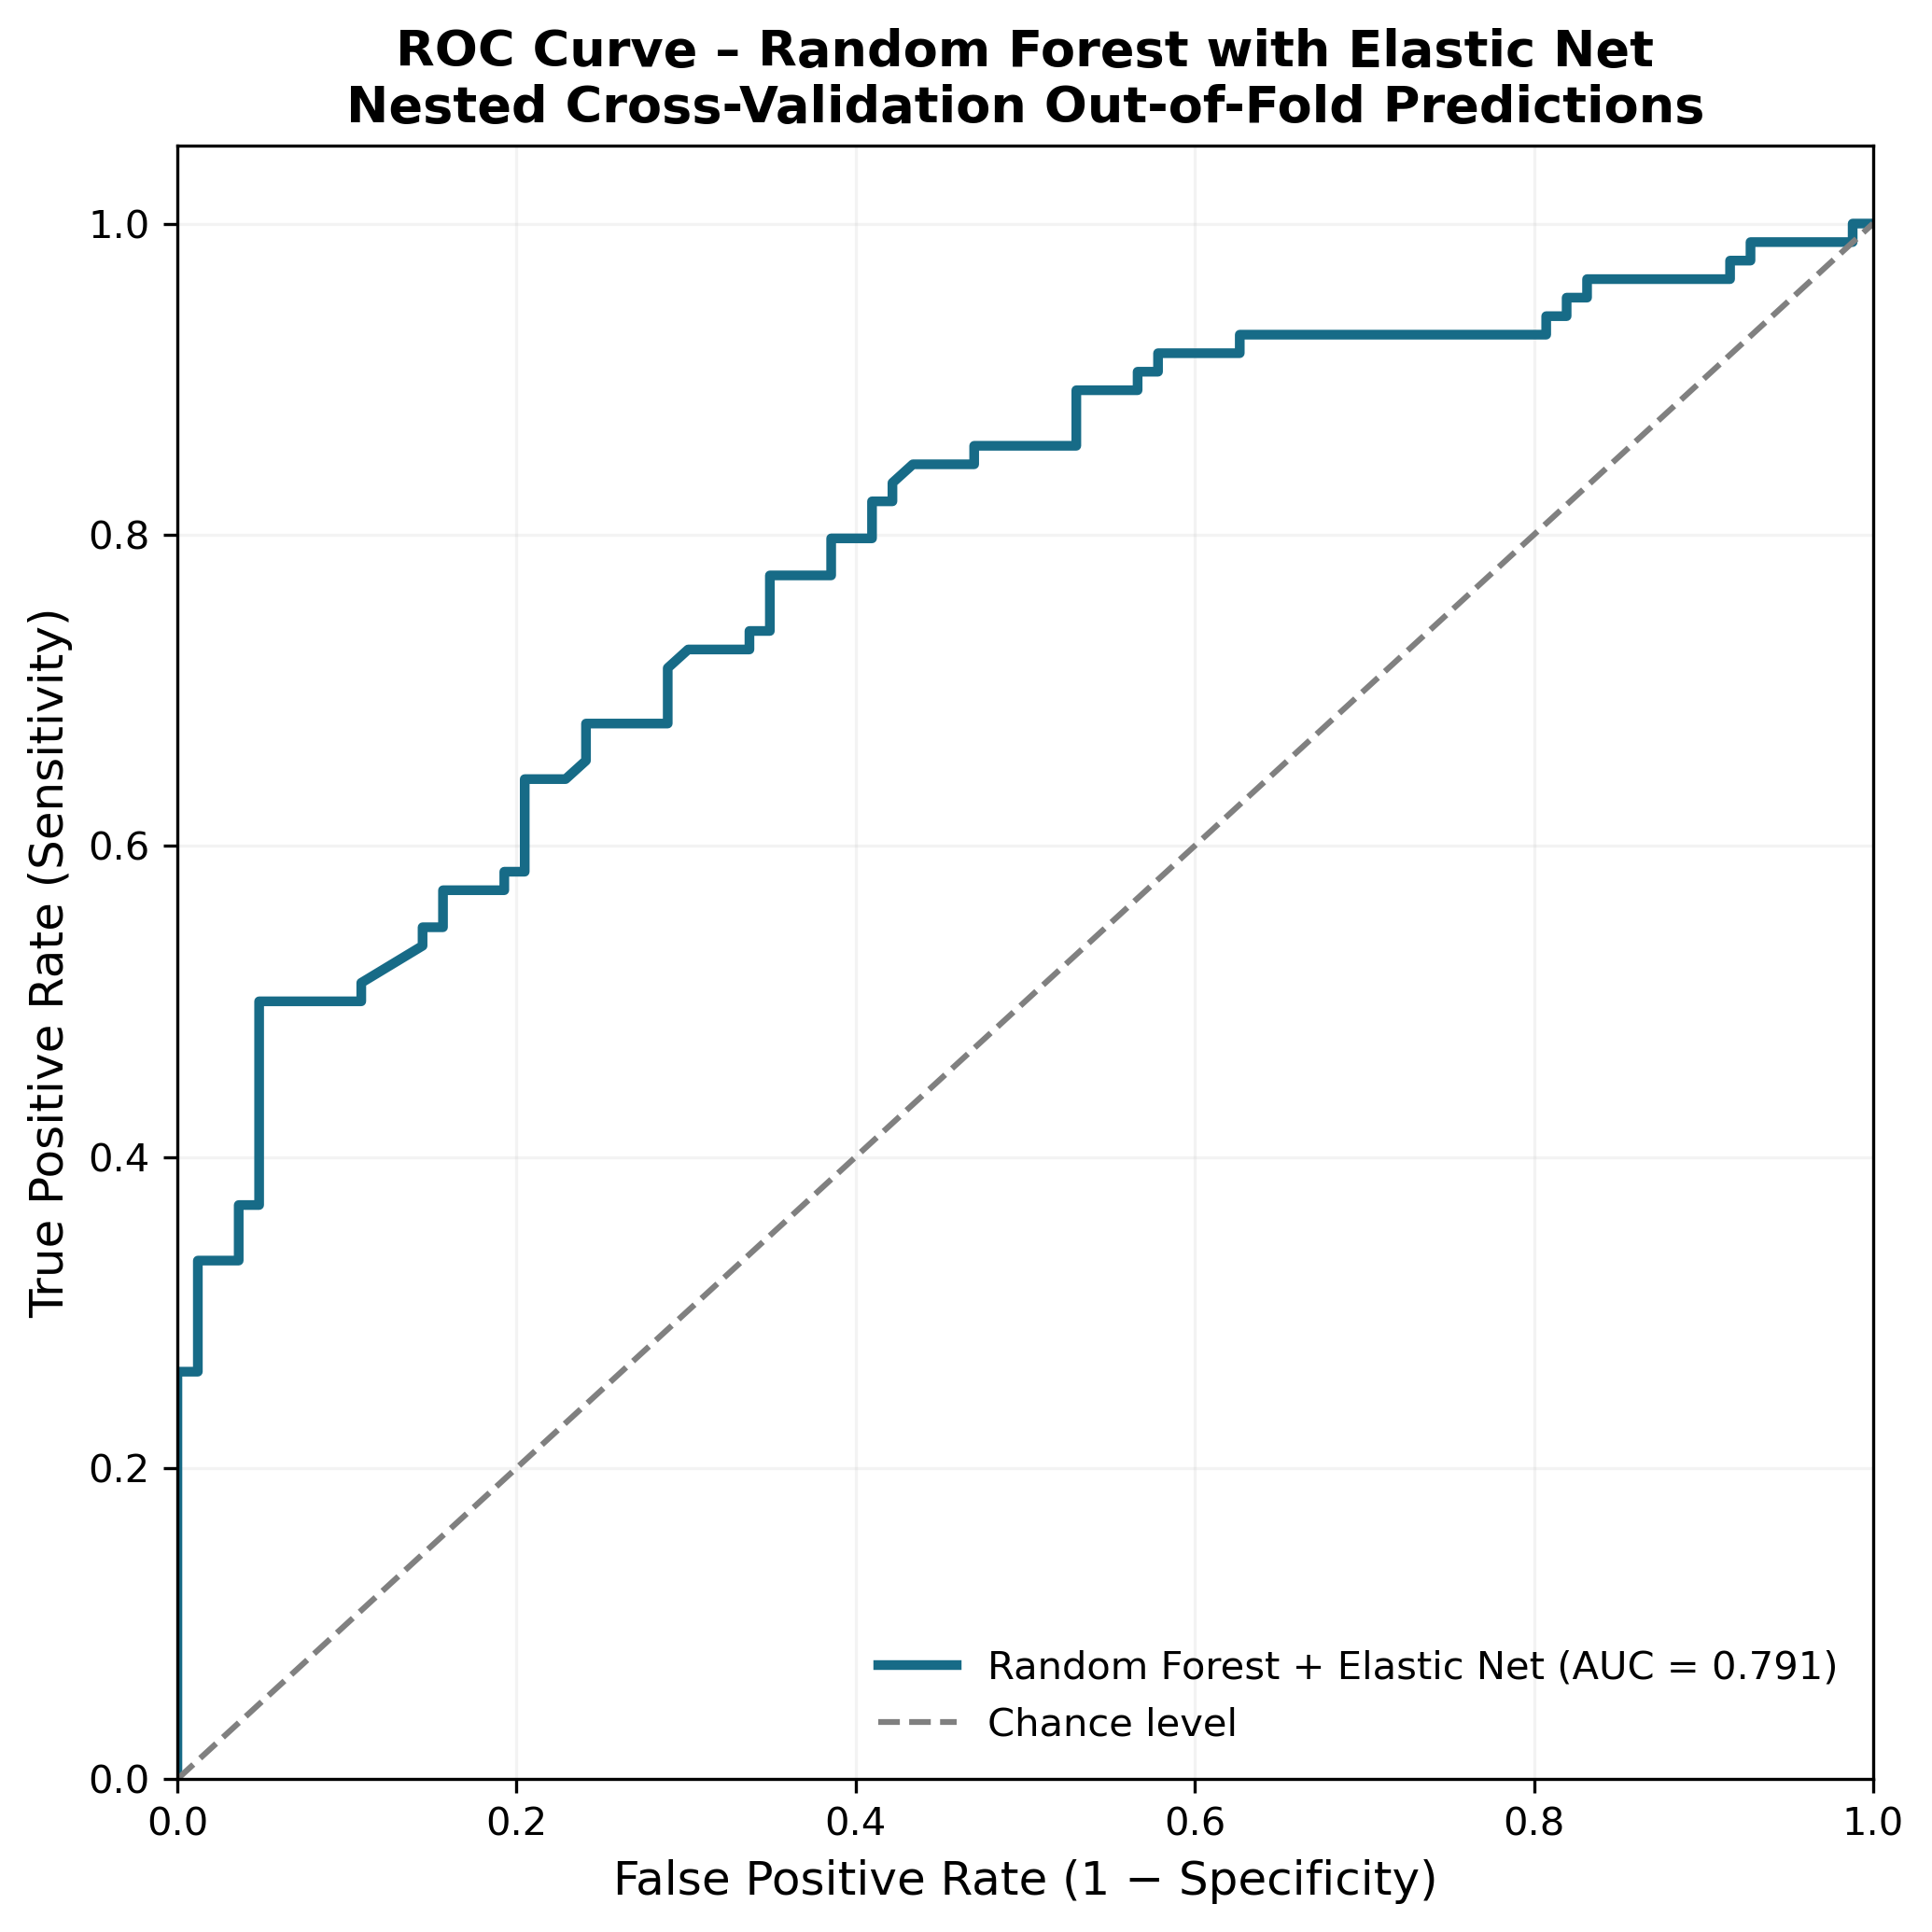

In [116]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    confusion_matrix,
    roc_curve,
    roc_auc_score
)

# ============================================================
# INPUTS: pooled outer-loop OOF results
# ============================================================

y_true = np.asarray(
    rf_elastic_without_sex_result["y_true"]
).ravel()

y_pred = np.asarray(
    rf_elastic_without_sex_result["oof_predictions"]
).ravel()

y_score = np.asarray(
    rf_elastic_without_sex_result["oof_scores"]
).ravel()


# ============================================================
# BASIC CHECKS
# ============================================================

if not (
    len(y_true) == len(y_pred) == len(y_score)
):
    raise ValueError(
        "y_true, y_pred, and y_score must have the same length."
    )

if not set(np.unique(y_true)).issubset({0, 1}):
    raise ValueError(
        "y_true must contain binary labels encoded as 0 and 1."
    )

if not set(np.unique(y_pred)).issubset({0, 1}):
    raise ValueError(
        "y_pred must contain binary predictions encoded as 0 and 1."
    )


# ============================================================
# 1. CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(
    y_true,
    y_pred,
    labels=[0, 1]
)

tn, fp, fn, tp = cm.ravel()

confusion_matrix_df = pd.DataFrame(
    cm,
    index=[
        "Actual Control (0)",
        "Actual Epilepsy (1)"
    ],
    columns=[
        "Predicted Control (0)",
        "Predicted Epilepsy (1)"
    ]
)

print("\nConfusion Matrix:")
print(confusion_matrix_df)

print("\nTN =", tn)
print("FP =", fp)
print("FN =", fn)
print("TP =", tp)


# Save confusion matrix
confusion_matrix_df.to_csv(
    "RF_ElasticNet_OOF_Confusion_Matrix.csv",
    index=True
)


# ============================================================
# OPTIONAL: LONG-FORM CONFUSION MATRIX TABLE
# useful for supplementary material
# ============================================================

cm_summary = pd.DataFrame({
    "Outcome": [
        "True Negative",
        "False Positive",
        "False Negative",
        "True Positive"
    ],
    "Count": [
        tn,
        fp,
        fn,
        tp
    ]
})

cm_summary.to_csv(
    "RF_ElasticNet_OOF_Confusion_Matrix_Summary.csv",
    index=False
)


# ============================================================
# 2. ROC CURVE
# ============================================================

fpr, tpr, thresholds = roc_curve(
    y_true,
    y_score
)

auc_value = roc_auc_score(
    y_true,
    y_score
)

print(
    f"\nPooled OOF ROC-AUC = {auc_value:.4f}"
)


# ============================================================
# SAVE ROC COORDINATES
# ============================================================

roc_coordinates = pd.DataFrame({
    "False Positive Rate": fpr,
    "True Positive Rate": tpr,
    "Threshold": thresholds
})

roc_coordinates.to_csv(
    "RF_ElasticNet_OOF_ROC_Coordinates.csv",
    index=False
)


# ============================================================
# CREATE PUBLICATION-STYLE ROC FIGURE
# ============================================================

plt.figure(
    figsize=(7, 7),
    dpi=300
)

plt.plot(
    fpr,
    tpr,
    color="#176B87",
    linewidth=2.5,
    label=(
        f"Random Forest + Elastic Net "
        f"(AUC = {auc_value:.3f})"
    )
)

# Chance line
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    color="gray",
    linewidth=1.5,
    label="Chance level"
)

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])

plt.xlabel(
    "False Positive Rate (1 − Specificity)",
    fontsize=12
)

plt.ylabel(
    "True Positive Rate (Sensitivity)",
    fontsize=12
)

plt.title(
    "ROC Curve – Random Forest with Elastic Net\n"
    "Nested Cross-Validation Out-of-Fold Predictions",
    fontsize=13,
    fontweight="bold"
)

plt.legend(
    loc="lower right",
    frameon=False,
    fontsize=10
)

plt.grid(
    alpha=0.15
)

plt.tight_layout()


# ============================================================
# SAVE HIGH-RESOLUTION FIGURES
# ============================================================

plt.savefig(
    "RF_ElasticNet_OOF_ROC_Curve.png",
    dpi=600,
    bbox_inches="tight"
)

# Vector format — preferable for journal production
plt.savefig(
    "RF_ElasticNet_OOF_ROC_Curve.pdf",
    bbox_inches="tight"
)

plt.show()

Most balanced threshold = 0.490
Precision at this threshold = 0.714
Recall at this threshold = 0.714


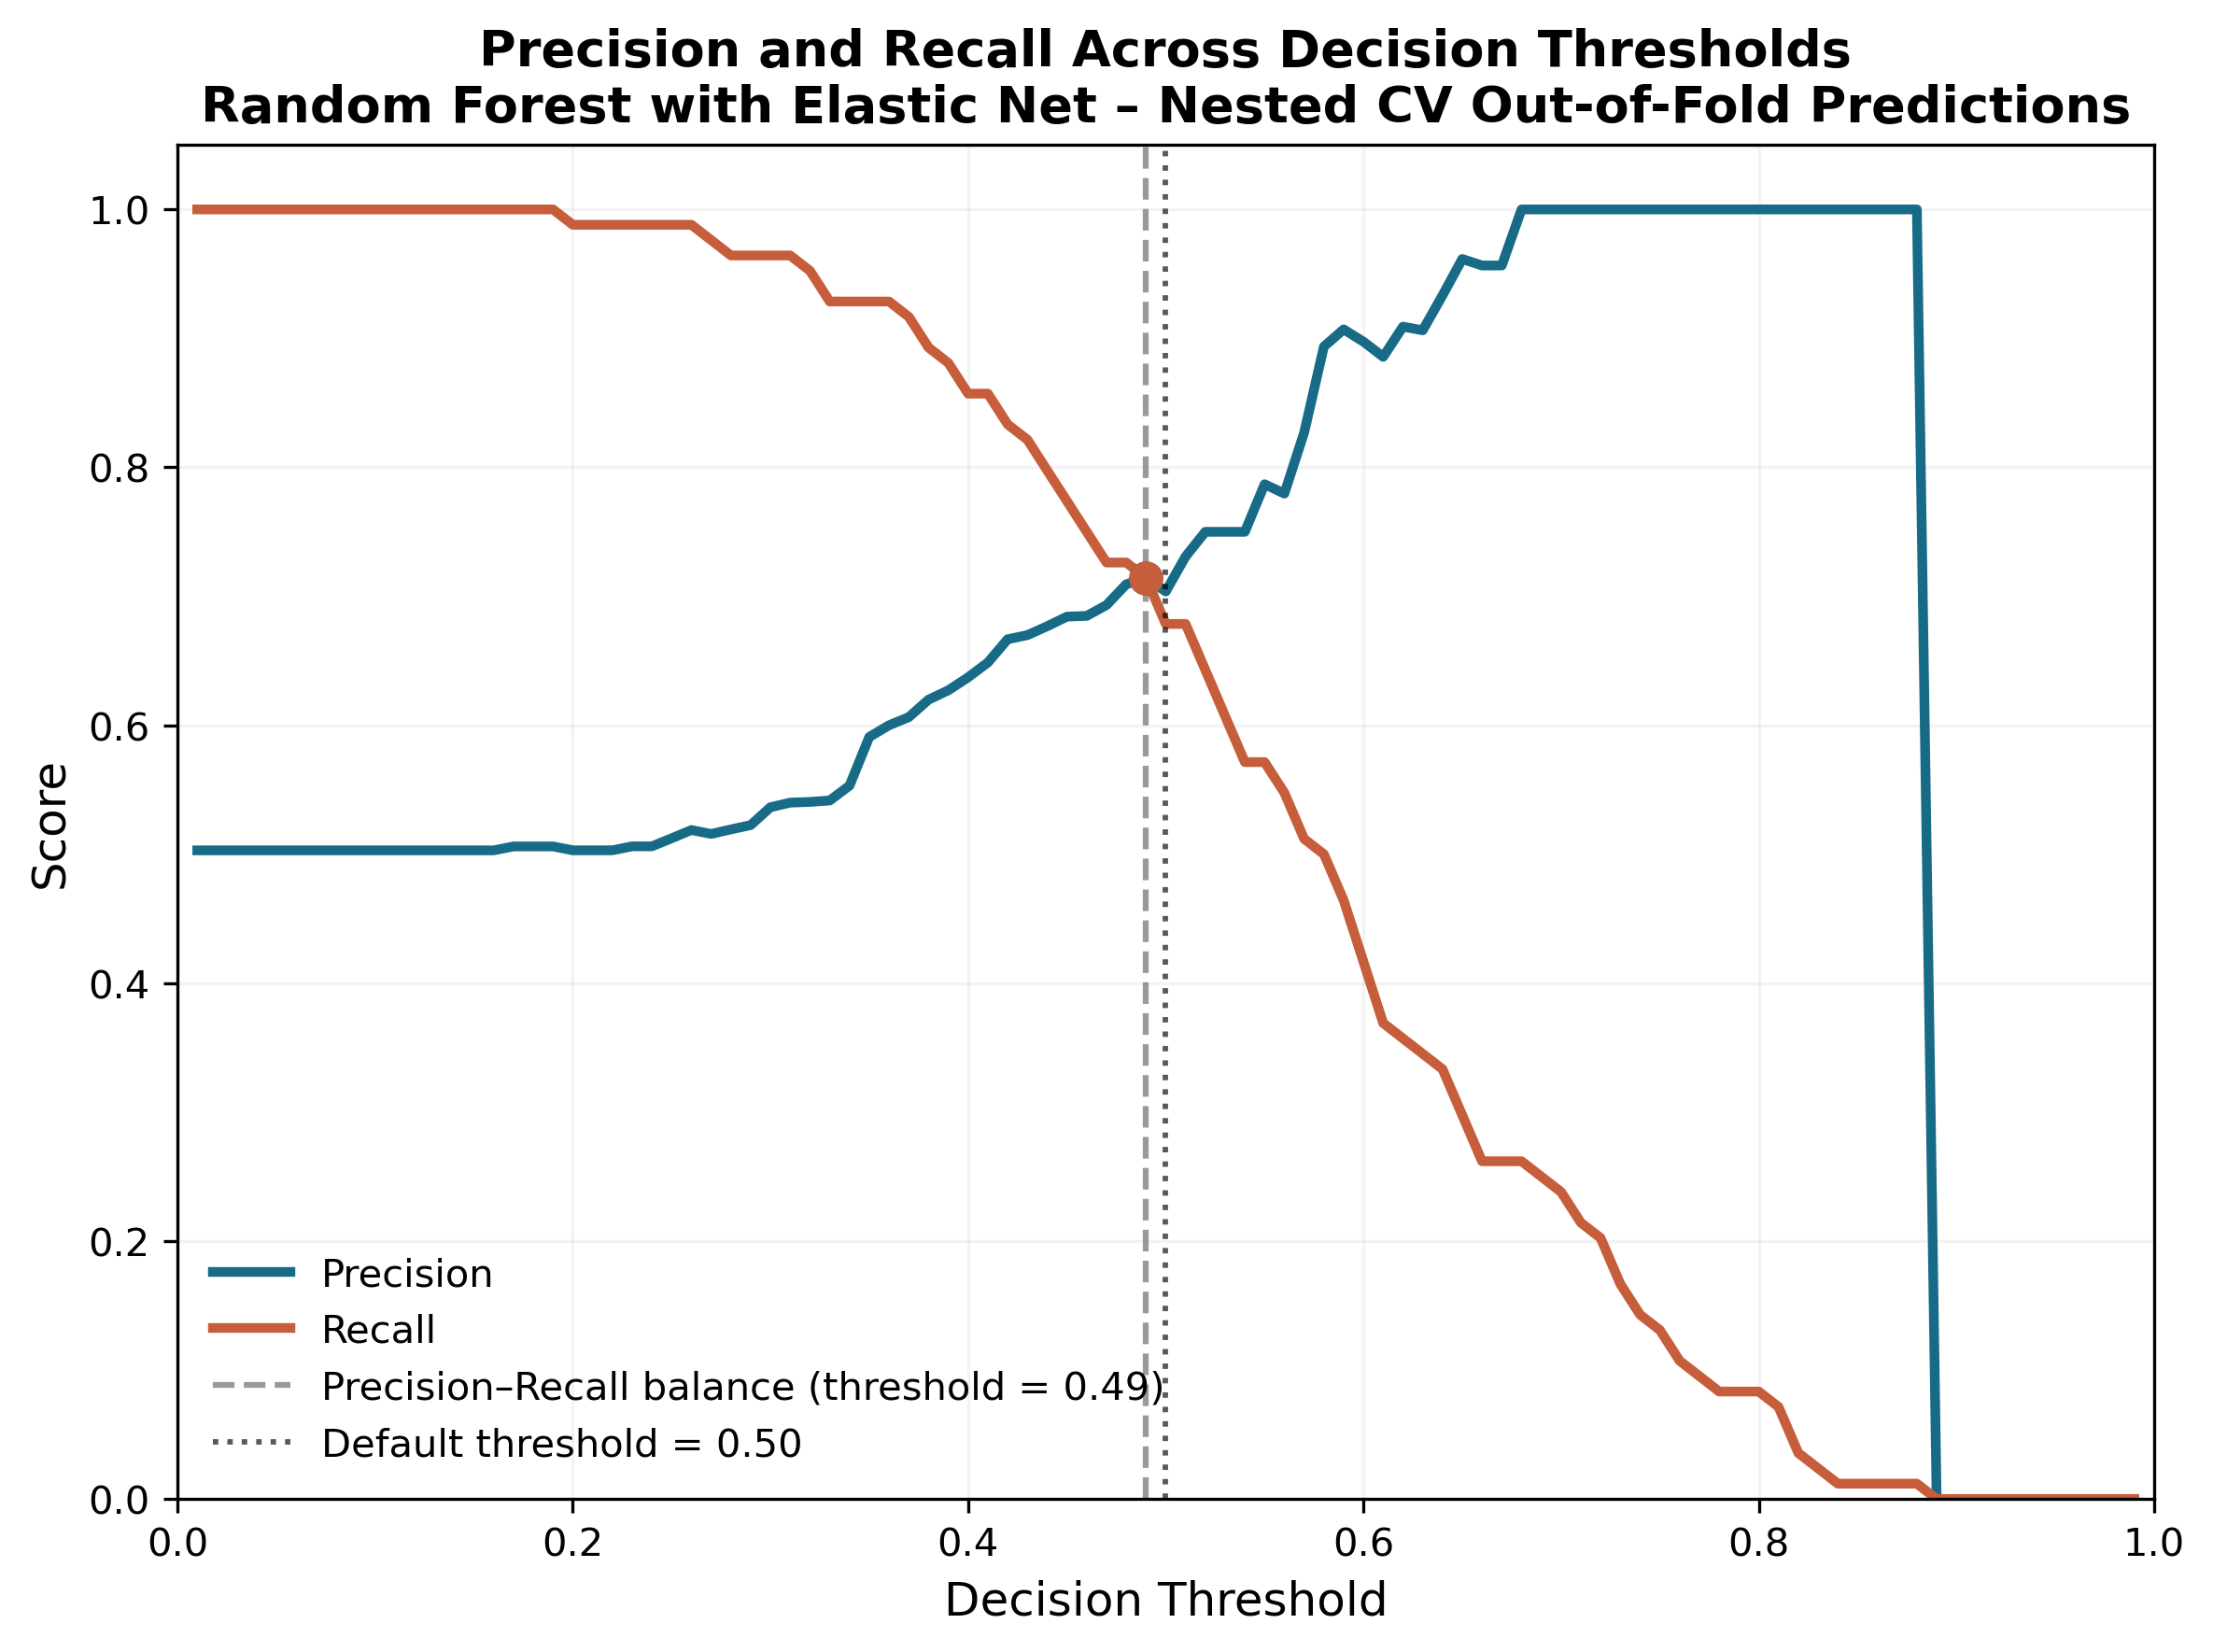

In [118]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    precision_score,
    recall_score
)


# ============================================================
# INPUTS: pooled outer-loop OOF results
# ============================================================

y_true = np.asarray(
    rf_elastic_without_sex_result["y_true"]
).ravel()

y_score = np.asarray(
    rf_elastic_without_sex_result["oof_scores"]
).ravel()


# ============================================================
# BASIC CHECKS
# ============================================================

if len(y_true) != len(y_score):
    raise ValueError(
        "y_true and y_score must have the same length."
    )

if not set(np.unique(y_true)).issubset({0, 1}):
    raise ValueError(
        "y_true must contain binary labels encoded as 0 and 1."
    )

if not np.all(np.isfinite(y_score)):
    raise ValueError(
        "y_score contains NaN or infinite values."
    )


# ============================================================
# DEFINE THRESHOLDS
# ============================================================

thresholds = np.linspace(
    0.01,
    0.99,
    99
)


precision_values = []
recall_values = []


# ============================================================
# CALCULATE PRECISION AND RECALL AT EACH THRESHOLD
# ============================================================

for threshold in thresholds:

    y_pred_threshold = (
        y_score >= threshold
    ).astype(int)

    precision = precision_score(
        y_true,
        y_pred_threshold,
        zero_division=0
    )

    recall = recall_score(
        y_true,
        y_pred_threshold,
        zero_division=0
    )

    precision_values.append(
        precision
    )

    recall_values.append(
        recall
    )


precision_values = np.asarray(
    precision_values
)

recall_values = np.asarray(
    recall_values
)


# ============================================================
# FIND THRESHOLD WHERE PRECISION AND RECALL ARE MOST BALANCED
# ============================================================

difference = np.abs(
    precision_values
    -
    recall_values
)

balanced_index = np.argmin(
    difference
)

balanced_threshold = thresholds[
    balanced_index
]

balanced_precision = precision_values[
    balanced_index
]

balanced_recall = recall_values[
    balanced_index
]


print(
    f"Most balanced threshold = "
    f"{balanced_threshold:.3f}"
)

print(
    f"Precision at this threshold = "
    f"{balanced_precision:.3f}"
)

print(
    f"Recall at this threshold = "
    f"{balanced_recall:.3f}"
)


# ============================================================
# SAVE THRESHOLD DATA AS CSV
# ============================================================

threshold_metrics = pd.DataFrame({
    "Threshold": thresholds,
    "Precision": precision_values,
    "Recall": recall_values
})

threshold_metrics[
    "Absolute Precision-Recall Difference"
] = np.abs(
    threshold_metrics["Precision"]
    -
    threshold_metrics["Recall"]
)

threshold_metrics.to_csv(
    "RF_ElasticNet_OOF_Precision_Recall_by_Threshold.csv",
    index=False
)


# ============================================================
# PUBLICATION-STYLE FIGURE
# ============================================================

plt.figure(
    figsize=(8, 6),
    dpi=300
)


# Precision curve
plt.plot(
    thresholds,
    precision_values,
    color="#176B87",
    linewidth=2.5,
    label="Precision"
)


# Recall curve
plt.plot(
    thresholds,
    recall_values,
    color="#C65D3B",
    linewidth=2.5,
    label="Recall"
)


# ============================================================
# SHOW BALANCED THRESHOLD
# ============================================================

plt.axvline(
    x=balanced_threshold,
    color="gray",
    linestyle="--",
    linewidth=1.5,
    alpha=0.8,
    label=(
        "Precision–Recall balance "
        f"(threshold = {balanced_threshold:.2f})"
    )
)


plt.scatter(
    balanced_threshold,
    balanced_precision,
    color="#176B87",
    s=60,
    zorder=5
)

plt.scatter(
    balanced_threshold,
    balanced_recall,
    color="#C65D3B",
    s=60,
    zorder=5
)


# ============================================================
# DEFAULT 0.50 THRESHOLD
# ============================================================

plt.axvline(
    x=0.50,
    color="black",
    linestyle=":",
    linewidth=1.4,
    alpha=0.65,
    label="Default threshold = 0.50"
)


# ============================================================
# FORMATTING
# ============================================================

plt.xlim(
    0,
    1
)

plt.ylim(
    0,
    1.05
)

plt.xlabel(
    "Decision Threshold",
    fontsize=12
)

plt.ylabel(
    "Score",
    fontsize=12
)

plt.title(
    "Precision and Recall Across Decision Thresholds\n"
    "Random Forest with Elastic Net – "
    "Nested CV Out-of-Fold Predictions",
    fontsize=13,
    fontweight="bold"
)

plt.legend(
    loc="best",
    frameon=False,
    fontsize=10
)

plt.grid(
    alpha=0.15
)

plt.tight_layout()


# ============================================================
# SAVE FIGURE
# ============================================================

plt.savefig(
    "RF_ElasticNet_OOF_Precision_Recall_vs_Threshold.png",
    dpi=600,
    bbox_inches="tight"
)

plt.savefig(
    "RF_ElasticNet_OOF_Precision_Recall_vs_Threshold.pdf",
    bbox_inches="tight"
)

plt.show()

In [119]:
df=pd.read_csv('df_destx.csv')
mri_negative_histopath_positive = df[
    (
        df['histopathology'].notna()
    )
    &
    (
        df['mri_diagnosis'].isin(['none', 'other'])
    )
]

In [120]:
mri_negative_histopath_positive.drop(['Unnamed: 0.1','Unnamed: 0','age_epilepsyonset','map','spect','pet','invasive_EEG','op','age_op','histopathology','1year_outcome','latest_outcome','time_follow-up','hemisphere','lobe'],axis=1,inplace=True)

In [129]:
mnhp_cat,mnhp_num=DataFrameSplitter(mri_negative_histopath_positive)

In [130]:
CatCorrector(mnhp_cat)

In [156]:
mnhp_cat.age_scan=ordinal_encoder.transform(mnhp_cat[['age_scan']])

In [165]:
X_mri_negative_histopath_positive=pd.concat([mnhp_cat,mnhp_num], axis=1)

In [166]:
X_mri_negative_histopath_positive.drop(['group','sex','mri_diagnosis'],axis=1, inplace = True)

In [167]:
X_mri_negative_histopath_positive

,age_scan,Left-Lateral-VentricleVolume_mm3,Left-Inf-Lat-VentVolume_mm3,Left-Cerebellum-White-MatterVolume_mm3,Left-Cerebellum-CortexVolume_mm3,Left-ThalamusVolume_mm3,Left-CaudateVolume_mm3,Left-PutamenVolume_mm3,Left-PallidumVolume_mm3,3rd-VentricleVolume_mm3,...,RightDestxS_temporal_supFoldInd,RightDestxS_temporal_supCurvInd,RightDestxS_temporal_transverseSurfArea_mm2,RightDestxS_temporal_transverseGrayVol_mm2,RightDestxS_temporal_transverseThickAvg_mm,RightDestxS_temporal_transverseThickStd_mm,RightDestxS_temporal_transverseMeanCurv_mm^-1,RightDestxS_temporal_transverseGausCurv_m^-2,RightDestxS_temporal_transverseFoldInd,RightDestxS_temporal_transverseCurvInd
60,2.0,6196.4,381.4,17305.2,66079.2,9243.1,3659.1,5093.6,2254.8,1036.6,...,38,4.2,251,533,251,0.501,0.112,0.015,2,0.2
64,3.0,3028.9,286.2,7095.4,34449.4,6901.0,3601.0,4704.8,1800.8,516.7,...,36,4.6,237,484,237,0.337,0.132,0.021,4,0.3
69,2.0,10375.0,359.3,15779.0,65345.2,8169.8,4386.6,5401.5,2212.6,1411.8,...,37,4.3,126,288,126,0.315,0.138,0.021,2,0.2
72,1.0,5193.5,576.7,12486.7,51645.8,8345.8,3865.7,4594.5,1932.5,1093.3,...,41,5.5,217,469,217,0.338,0.126,0.023,2,0.3
97,2.0,8025.7,330.3,15747.5,63279.8,9294.9,3952.6,5160.6,2187.1,1151.7,...,42,5.3,175,341,175,0.420,0.148,0.022,2,0.3
104,2.0,8837.3,178.4,21656.2,65985.3,9629.8,3920.9,3835.6,2169.6,1179.2,...,53,6.5,149,339,149,0.622,0.147,0.029,2,0.3


In [168]:
X_mri_negative_histopath_positive.to_csv('X_mri_negative_histopath_positive.csv')

In [170]:
mri_negative = pd.read_csv(
    "X_mri_negative_histopath_positive.csv"
)

In [171]:
mri_negative

,Unnamed: 0,age_scan,Left-Lateral-VentricleVolume_mm3,Left-Inf-Lat-VentVolume_mm3,Left-Cerebellum-White-MatterVolume_mm3,Left-Cerebellum-CortexVolume_mm3,Left-ThalamusVolume_mm3,Left-CaudateVolume_mm3,Left-PutamenVolume_mm3,Left-PallidumVolume_mm3,...,RightDestxS_temporal_supFoldInd,RightDestxS_temporal_supCurvInd,RightDestxS_temporal_transverseSurfArea_mm2,RightDestxS_temporal_transverseGrayVol_mm2,RightDestxS_temporal_transverseThickAvg_mm,RightDestxS_temporal_transverseThickStd_mm,RightDestxS_temporal_transverseMeanCurv_mm^-1,RightDestxS_temporal_transverseGausCurv_m^-2,RightDestxS_temporal_transverseFoldInd,RightDestxS_temporal_transverseCurvInd
0,60,2.0,6196.4,381.4,17305.2,66079.2,9243.1,3659.1,5093.6,2254.8,...,38,4.2,251,533,251,0.501,0.112,0.015,2,0.2
1,64,3.0,3028.9,286.2,7095.4,34449.4,6901.0,3601.0,4704.8,1800.8,...,36,4.6,237,484,237,0.337,0.132,0.021,4,0.3
2,69,2.0,10375.0,359.3,15779.0,65345.2,8169.8,4386.6,5401.5,2212.6,...,37,4.3,126,288,126,0.315,0.138,0.021,2,0.2
3,72,1.0,5193.5,576.7,12486.7,51645.8,8345.8,3865.7,4594.5,1932.5,...,41,5.5,217,469,217,0.338,0.126,0.023,2,0.3
4,97,2.0,8025.7,330.3,15747.5,63279.8,9294.9,3952.6,5160.6,2187.1,...,42,5.3,175,341,175,0.420,0.148,0.022,2,0.3
5,104,2.0,8837.3,178.4,21656.2,65985.3,9629.8,3920.9,3835.6,2169.6,...,53,6.5,149,339,149,0.622,0.147,0.029,2,0.3


In [172]:
subgroup_indices = (
    mri_negative["Unnamed: 0"]
    .astype(int)
    .to_numpy()
)

print(
    "MRI-negative / pathology-positive indices:"
)

print(subgroup_indices)

MRI-negative / pathology-positive indices:
[ 60  64  69  72  97 104]


In [173]:
import numpy as np
import pandas as pd

y_true = np.asarray(
    rf_elastic_without_sex_result[
        "y_true"
    ]
)

y_pred = np.asarray(
    rf_elastic_without_sex_result[
        "oof_predictions"
    ]
)

y_score = np.asarray(
    rf_elastic_without_sex_result[
        "oof_scores"
    ]
)


subgroup_results = pd.DataFrame({

    "Original_Index":
        subgroup_indices,

    "True_Label":
        y_true[subgroup_indices],

    "OOF_Predicted_Label":
        y_pred[subgroup_indices],

    "OOF_Epilepsy_Score":
        y_score[subgroup_indices]
})

In [174]:
subgroup_results[
    "Correct_Prediction"
] = (
    subgroup_results[
        "True_Label"
    ]
    ==
    subgroup_results[
        "OOF_Predicted_Label"
    ]
)

In [175]:
if not np.all(
    subgroup_results["True_Label"] == 1
):
    raise ValueError(
        "At least one selected subject has "
        "True_Label != 1. Check whether the "
        "original indices correspond to row "
        "positions used in Nested CV."
    )

In [176]:
print(
    subgroup_results.to_string(
        index=False
    )
)

 Original_Index  True_Label  OOF_Predicted_Label  OOF_Epilepsy_Score  Correct_Prediction
             60           1                    0            0.320000               False
             64           1                    1            0.577811                True
             69           1                    0            0.390123               False
             72           1                    1            0.885000                True
             97           1                    0            0.395000               False
            104           1                    1            0.733542                True


In [177]:
n_total = len(
    subgroup_results
)

n_detected = (
    subgroup_results[
        "OOF_Predicted_Label"
    ] == 1
).sum()

exploratory_sensitivity = (
    n_detected / n_total
)


print(
    f"\nCorrectly identified as epilepsy: "
    f"{n_detected}/{n_total}"
)

print(
    f"Exploratory subgroup sensitivity: "
    f"{exploratory_sensitivity:.3f} "
    f"({exploratory_sensitivity*100:.1f}%)"
)


Correctly identified as epilepsy: 3/6
Exploratory subgroup sensitivity: 0.500 (50.0%)


In [178]:
subgroup_results.to_csv(
    "MRInegative_HistopathPositive_OOF_Predictions.csv",
    index=False
)

In [179]:
print(subgroup_indices)

print(
    y_true[subgroup_indices]
)

[ 60  64  69  72  97 104]
[1 1 1 1 1 1]


In [180]:
# Pick the first MRI feature shared by both datasets
common_features = [
    c for c in X.columns
    if c in mri_negative.columns
    and c != AGE_COLUMN
]

check_feature = common_features[0]

mapping_check = pd.DataFrame({

    "Index":
        subgroup_indices,

    "Original_X_Value":
        X.iloc[subgroup_indices][
            check_feature
        ].to_numpy(),

    "Subgroup_File_Value":
        mri_negative[
            check_feature
        ].to_numpy()
})

mapping_check[
    "Match"
] = np.isclose(
    mapping_check[
        "Original_X_Value"
    ],
    mapping_check[
        "Subgroup_File_Value"
    ],
    equal_nan=True
)

print(mapping_check)

print(
    "\nAll rows correctly matched:",
    mapping_check["Match"].all()
)

   Index  Original_X_Value  Subgroup_File_Value  Match
0     60            6196.4               6196.4   True
1     64            3028.9               3028.9   True
2     69           10375.0              10375.0   True
3     72            5193.5               5193.5   True
4     97            8025.7               8025.7   True
5    104            8837.3               8837.3   True

All rows correctly matched: True


In [181]:
import numpy as np
import pandas as pd

from statsmodels.stats.contingency_tables import mcnemar


def compare_classifiers_with_mcnemar(
    y_true,
    predictions_a,
    predictions_b,
    model_a_name="Model A",
    model_b_name="Model B",
    exact_threshold=25
):
    """
    Paired comparison of binary classification errors
    using McNemar's test.
    """

    y_true = np.asarray(y_true).ravel()
    predictions_a = np.asarray(predictions_a).ravel()
    predictions_b = np.asarray(predictions_b).ravel()

    if not (
        len(y_true)
        == len(predictions_a)
        == len(predictions_b)
    ):
        raise ValueError(
            "y_true and both prediction arrays "
            "must have the same length."
        )

    correct_a = predictions_a == y_true
    correct_b = predictions_b == y_true

    both_incorrect = int(
        np.sum(
            (~correct_a) & (~correct_b)
        )
    )

    a_incorrect_b_correct = int(
        np.sum(
            (~correct_a) & correct_b
        )
    )

    a_correct_b_incorrect = int(
        np.sum(
            correct_a & (~correct_b)
        )
    )

    both_correct = int(
        np.sum(
            correct_a & correct_b
        )
    )

    table = np.array([
        [
            both_incorrect,
            a_incorrect_b_correct
        ],
        [
            a_correct_b_incorrect,
            both_correct
        ]
    ])

    discordant_pairs = (
        a_incorrect_b_correct
        + a_correct_b_incorrect
    )

    use_exact = (
        discordant_pairs < exact_threshold
    )

    result = mcnemar(
        table,
        exact=use_exact,
        correction=not use_exact
    )

    readable_table = pd.DataFrame(
        table,
        index=[
            f"{model_a_name} incorrect",
            f"{model_a_name} correct"
        ],
        columns=[
            f"{model_b_name} incorrect",
            f"{model_b_name} correct"
        ]
    )

    return {
        "contingency_table": readable_table,

        "both_incorrect":
            both_incorrect,

        "model_a_only_correct":
            a_correct_b_incorrect,

        "model_b_only_correct":
            a_incorrect_b_correct,

        "both_correct":
            both_correct,

        "discordant_pairs":
            discordant_pairs,

        "test":
            (
                "Exact McNemar"
                if use_exact
                else
                "McNemar with continuity correction"
            ),

        "statistic":
            float(result.statistic),

        "p_value":
            float(result.pvalue)
    }

In [182]:
def run_mcnemar_comparison(
    result_a,
    result_b,
    model_a_name,
    model_b_name,
    comparison_name
):
    """
    Run McNemar test using OOF predictions stored
    in two nested-CV result objects.
    """

    required_keys = {
        "y_true",
        "oof_predictions"
    }

    for name, result in {
        model_a_name: result_a,
        model_b_name: result_b
    }.items():

        missing = required_keys.difference(
            result.keys()
        )

        if missing:
            raise KeyError(
                f"{name} is missing: "
                f"{sorted(missing)}"
            )

    y_true_a = np.asarray(
        result_a["y_true"]
    ).ravel()

    y_true_b = np.asarray(
        result_b["y_true"]
    ).ravel()

    # Critical check:
    # paired comparison requires identical participant order
    if not np.array_equal(
        y_true_a,
        y_true_b
    ):
        raise ValueError(
            f"{comparison_name}: y_true arrays "
            "are not identical. Check participant "
            "ordering before performing McNemar."
        )

    result = compare_classifiers_with_mcnemar(
        y_true=y_true_a,

        predictions_a=result_a[
            "oof_predictions"
        ],

        predictions_b=result_b[
            "oof_predictions"
        ],

        model_a_name=model_a_name,
        model_b_name=model_b_name
    )

    summary_row = {
        "Comparison":
            comparison_name,

        "Model A":
            model_a_name,

        "Model B":
            model_b_name,

        "Both incorrect":
            result["both_incorrect"],

        "Model A only correct":
            result["model_a_only_correct"],

        "Model B only correct":
            result["model_b_only_correct"],

        "Both correct":
            result["both_correct"],

        "Discordant pairs":
            result["discordant_pairs"],

        "McNemar test":
            result["test"],

        "Statistic":
            result["statistic"],

        "P-value":
            result["p_value"],

        "Significant":
            result["p_value"] < 0.05
    }

    return result, summary_row

In [183]:
mcnemar_1, summary_1 = (
    run_mcnemar_comparison(
        result_a=rf_pca_without_sex_result,

        result_b=rf_elastic_without_sex_result,

        model_a_name="RF + PCA",
        model_b_name="RF + Elastic Net",

        comparison_name=(
            "Feature-reduction method"
        )
    )
)

print("\n" + "=" * 80)
print("1. RF + PCA vs RF + Elastic Net")
print("=" * 80)

print(
    mcnemar_1["contingency_table"]
)

print(
    f"\nTest: {mcnemar_1['test']}"
)

print(
    f"Statistic: "
    f"{mcnemar_1['statistic']:.4f}"
)

print(
    f"P-value: "
    f"{mcnemar_1['p_value']:.6f}"
)


1. RF + PCA vs RF + Elastic Net
                    RF + Elastic Net incorrect  RF + Elastic Net correct
RF + PCA incorrect                          32                        27
RF + PCA correct                            17                        91

Test: McNemar with continuity correction
Statistic: 1.8409
P-value: 0.174844


In [184]:
mcnemar_2, summary_2 = (
    run_mcnemar_comparison(
        result_a=rf_elastic_without_sex_result,

        result_b=rf_elastic_with_sex_result,

        model_a_name=(
            "RF + Elastic Net"
        ),

        model_b_name=(
            "RF + Elastic Net + Sex"
        ),

        comparison_name=(
            "Effect of adding sex "
            "within Elastic Net"
        )
    )
)

print("\n" + "=" * 80)
print(
    "2. RF + Elastic Net "
    "without vs with Sex"
)
print("=" * 80)

print(
    mcnemar_2["contingency_table"]
)

print(
    f"\nTest: {mcnemar_2['test']}"
)

print(
    f"Statistic: "
    f"{mcnemar_2['statistic']:.4f}"
)

print(
    f"P-value: "
    f"{mcnemar_2['p_value']:.6f}"
)


2. RF + Elastic Net without vs with Sex
                            RF + Elastic Net + Sex incorrect  \
RF + Elastic Net incorrect                                42   
RF + Elastic Net correct                                   4   

                            RF + Elastic Net + Sex correct  
RF + Elastic Net incorrect                               7  
RF + Elastic Net correct                               114  

Test: Exact McNemar
Statistic: 4.0000
P-value: 0.548828


In [186]:
mcnemar_3, summary_3 = (
    run_mcnemar_comparison(
        result_a=rf_pca_without_sex_result,

        result_b=rf_pca_sex_result,

        model_a_name=(
            "RF + PCA"
        ),

        model_b_name=(
            "RF + PCA + Sex"
        ),

        comparison_name=(
            "Effect of adding sex "
            "within PCA"
        )
    )
)

print("\n" + "=" * 80)
print(
    "3. RF + PCA "
    "without vs with Sex"
)
print("=" * 80)

print(
    mcnemar_3["contingency_table"]
)

print(
    f"\nTest: {mcnemar_3['test']}"
)

print(
    f"Statistic: "
    f"{mcnemar_3['statistic']:.4f}"
)

print(
    f"P-value: "
    f"{mcnemar_3['p_value']:.6f}"
)


3. RF + PCA without vs with Sex
                    RF + PCA + Sex incorrect  RF + PCA + Sex correct
RF + PCA incorrect                        50                       9
RF + PCA correct                           4                     104

Test: Exact McNemar
Statistic: 4.0000
P-value: 0.266846


In [187]:
mcnemar_4, summary_4 = (
    run_mcnemar_comparison(
        result_a=rf_elastic_without_sex_result,

        result_b=lgbm_elastic_without_sex_result,

        model_a_name=(
            "RF + Elastic Net"
        ),

        model_b_name=(
            "LightGBM + Elastic Net"
        ),

        comparison_name=(
            "Two highest-performing "
            "model-pipeline combinations"
        )
    )
)

print("\n" + "=" * 80)
print(
    "4. RF + Elastic Net "
    "vs LightGBM + Elastic Net"
)
print("=" * 80)

print(
    mcnemar_4["contingency_table"]
)

print(
    f"\nTest: {mcnemar_4['test']}"
)

print(
    f"Statistic: "
    f"{mcnemar_4['statistic']:.4f}"
)

print(
    f"P-value: "
    f"{mcnemar_4['p_value']:.6f}"
)


4. RF + Elastic Net vs LightGBM + Elastic Net
                            LightGBM + Elastic Net incorrect  \
RF + Elastic Net incorrect                                33   
RF + Elastic Net correct                                  15   

                            LightGBM + Elastic Net correct  
RF + Elastic Net incorrect                              16  
RF + Elastic Net correct                               103  

Test: McNemar with continuity correction
Statistic: 0.0000
P-value: 1.000000


In [188]:
mcnemar_summary_table = pd.DataFrame(
    [
        summary_1,
        summary_2,
        summary_3,
        summary_4
    ]
)

print(
    "\n" + "=" * 100
)

print(
    "SUMMARY OF ALL McNEMAR COMPARISONS"
)

print(
    "=" * 100
)

print(
    mcnemar_summary_table.to_string(
        index=False
    )
)


SUMMARY OF ALL McNEMAR COMPARISONS
                                        Comparison          Model A                Model B  Both incorrect  Model A only correct  Model B only correct  Both correct  Discordant pairs                       McNemar test  Statistic  P-value  Significant
                          Feature-reduction method         RF + PCA       RF + Elastic Net              32                    17                    27            91                44 McNemar with continuity correction   1.840909 0.174844        False
           Effect of adding sex within Elastic Net RF + Elastic Net RF + Elastic Net + Sex              42                     4                     7           114                11                      Exact McNemar   4.000000 0.548828        False
                   Effect of adding sex within PCA         RF + PCA         RF + PCA + Sex              50                     4                     9           104                13                      Exact M

In [189]:
mcnemar_summary_table.to_csv(
    "McNemar_all_selected_comparisons.csv",
    index=False
)